# Random Forests — Bagging, OOB Intuition, and Feature Importance

<hr>

<center>
<div>
<img src="https://raw.githubusercontent.com/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/main/notebooks/figures/mgmt_474_ai_logo_02-modified.png" width="200"/>
</div>
</center>

# <center><a class="tocSkip"></center>
# <center>QM47400 Predictive Analytics</center>
# <center>Professor: Davi Moreira </center>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/blob/main/notebooks/nb12_random_forests_importance.ipynb)

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. Explain how **bootstrap aggregation (bagging)** plus **random feature subsets** turn high-variance single trees into stable ensembles, on both classification and regression cases.
2. Fit `RandomForestClassifier` and `RandomForestRegressor` and demonstrate their CV-score lift over the single tree from nb11 and the **Week-2 reference** baselines.
3. Tune `n_estimators` and `max_features` under the same one-standard-error rule used in nb11.
4. Read the **Out-of-Bag (OOB) score** as a free, non-redundant validation signal — and know when to trust it vs cross-validation.
5. Build the **four-method feature-importance reconciliation table** (linear-coefficient / impurity / permutation / drop-column) — the course-wide reference table that nb15 relies on for interpretation.

---

> **📋 Participation Reminder:** This notebook contains **2 PAUSE-AND-DO exercises** — Exercise 1 on the classification track (RF tuning) and Exercise 2 on the regression track (RF tuning). Complete both before submitting your notebook.

---

## 💼 Why This Matters

The single decision tree from nb11 is high-variance: a small change in the training data flips the root split, and from there the entire tree restructures. Both the State Health Department's review board and HomeValue Analytics' deployment council asked the same follow-up question after seeing the tree: *"What happens to this model if you retrain it on next month's data?"*

The honest answer is *"a different tree"*, which is not the answer either stakeholder wanted. **Random forests** fix this by training many trees on bootstrap samples with random feature subsets, then averaging their predictions. No single tree dominates; the forest votes. Variance drops sharply, predictions stabilize, and you keep the ability to handle non-linearity that linear baselines cannot.

The cost is a loss of single-path interpretability — you can no longer trace a flowchart from root to leaf because there are 100 of them. In exchange you get:

- **Stable predictions** under retraining (bias unchanged, variance roughly cut by `1/n_estimators`).
- **Built-in OOB validation** — every tree was trained on a bootstrap sample, so the \~37% of training data left out of each tree is a free held-out set.
- **Four different views of feature importance** that, when they disagree, tell you something interesting about the data.

By the end of today, both the State Health Department's screening forest and HomeValue's price-prediction forest should beat their respective **Week-2 references** by a CI-clear margin. If they do not, the random forest has not earned its added complexity, and the linear baseline ships. That CI-clear discipline is the bar nb14's selection ceremony will enforce on a five-candidate field per case.

> **A question that often comes up here:** *"if a forest is just an average of trees, why do I need the four-method importance table?"* Because the average of trees is opaque. You cannot read 100 flowcharts. The importance table is the diagnostic that lets you answer the **"what is the model paying attention to?"** question without re-deriving it from the trees.

---

## 1. Setup — Imports, References, Helpers

The setup cell does five things at once: imports the random-forest estimators for both cases, locks `RANDOM_SEED = 474`, defines the **Week-2 reference pipelines** (`reference_clf` = LogReg(C=1.0); `reference_reg` = OLS) carried over from nb09, and registers the plot helpers nb11 introduced (`plot_train_val_curve`, `plot_predicted_vs_actual`) plus three new ones for this notebook (`plot_cv_ci`, `plot_importance_bars`, `plot_importance_heatmap`).

> 💡 **Gemini Prompt:** "Set up imports for sklearn RandomForestClassifier, RandomForestRegressor, DecisionTreeClassifier, DecisionTreeRegressor, LogisticRegression, LinearRegression, permutation_importance, cross_val_score, StratifiedKFold, KFold, load_breast_cancer, fetch_california_housing, StandardScaler, Pipeline. Set RANDOM_SEED = 474. Define reference_clf and reference_reg as the Week-2 baseline pipelines. Define helpers: plot_train_val_curve, plot_predicted_vs_actual, plot_cv_ci (dot plot with 95% CI bars across N models), plot_importance_bars (horizontal bar chart with optional error bars), plot_importance_heatmap (heatmap of feature ranks across methods)."
>
> **After running, verify:**
> - [ ] `RANDOM_SEED = 474`, `reference_clf` and `reference_reg` defined
> - [ ] All five plot helpers callable
> - [ ] No import errors


In [1]:
# Setup — imports, seed, Week-2 references, plot helpers
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.precision', 4)
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_SEED = 474
np.random.seed(RANDOM_SEED)

# --- Course color convention ---
CLF_COLOR = '#1f77b4'
REG_COLOR = '#ff7f0e'
GREY      = '#999999'

# --- Week-2 reference models (from nb09's CI-overlap test) ---
reference_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(C=1.0, random_state=RANDOM_SEED, max_iter=5000))
])
reference_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('reg',    LinearRegression())
])

# --- Helper 1 (from nb11): train-vs-CV overfitting curve ---
def plot_train_val_curve(x_values, train, val_mean, val_std, xlabel, ylabel, title, ax,
                         color_train=GREY, color_val=CLF_COLOR):
    xs = list(range(len(x_values)))
    ax.plot(xs, train, marker='o', label='Train', linewidth=2, color=color_train)
    ax.errorbar(xs, val_mean, yerr=val_std, marker='s', label='5-fold CV ± SD',
                linewidth=2, capsize=5, color=color_val)
    ax.set_xticks(xs); ax.set_xticklabels([str(v) for v in x_values])
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)

# --- Helper 2 (from nb11): predicted-vs-actual scatter ---
def plot_predicted_vs_actual(y_true, y_pred, ax, title='Predicted vs Actual',
                             color=REG_COLOR):
    ax.scatter(y_true, y_pred, alpha=0.25, s=8, color=color)
    lo, hi = float(min(np.min(y_true), np.min(y_pred))), float(max(np.max(y_true), np.max(y_pred)))
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, label='Perfect prediction')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)

# --- Helper 3 (NEW): CV-CI dot plot (with 95% CI from Student's t) ---
def plot_cv_ci(scores_dict, metric_name, title, ax, color=CLF_COLOR, k=5):
    """scores_dict: {model_name: array of fold scores}; draws 95% CI from t-dist."""
    t_crit = stats.t.ppf(0.975, df=k - 1)
    rows = []
    for name, scores in scores_dict.items():
        m = float(np.mean(scores)); sd = float(np.std(scores, ddof=1))
        rows.append({'name': name, 'mean': m, 'half_w': t_crit * sd / np.sqrt(k)})
    df = pd.DataFrame(rows).sort_values('mean')
    ax.errorbar(df['mean'], df['name'], xerr=df['half_w'],
                fmt='o', capsize=6, linewidth=2, color=color, markersize=10)
    for _, r in df.iterrows():
        ax.text(r['mean'] + r['half_w'] + (r['half_w']*0.2 if r['half_w']>0 else 0.001),
                r['name'], f"{r['mean']:.4f}", va='center', fontsize=9)
    ax.set_xlabel(f'5-fold CV {metric_name} (mean ± 95% CI)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

# --- Helper 4 (NEW): horizontal importance bar chart with optional error bars ---
def plot_importance_bars(importances, names, ax, errors=None, color=CLF_COLOR,
                         title='Feature importance', top_n=15):
    """Horizontal bar chart, sorted descending. errors optional (e.g., permutation SD)."""
    df = pd.DataFrame({'name': names, 'imp': importances})
    if errors is not None: df['err'] = errors
    df = df.sort_values('imp', ascending=True).tail(top_n)
    if errors is not None:
        ax.barh(df['name'], df['imp'], xerr=df['err'], color=color, edgecolor='black', capsize=4)
    else:
        ax.barh(df['name'], df['imp'], color=color, edgecolor='black')
    ax.set_xlabel('Importance')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

# --- Helper 5 (NEW): rank-disagreement heatmap (4-method reconciliation) ---
def plot_importance_heatmap(rank_df, ax, title='Feature rank across methods', top_n=15):
    """rank_df: rows = features, columns = methods; values = rank (1 = most important)."""
    # Show only top_n features by best (smallest) rank across methods
    best_rank = rank_df.min(axis=1)
    keep = best_rank.nsmallest(top_n).index
    sub = rank_df.loc[keep].sort_values(rank_df.columns[0])
    im = ax.imshow(sub.values, cmap='RdYlGn_r', aspect='auto', vmin=1, vmax=rank_df.shape[0])
    ax.set_xticks(range(sub.shape[1])); ax.set_xticklabels(sub.columns, rotation=20, ha='right')
    ax.set_yticks(range(sub.shape[0])); ax.set_yticklabels(sub.index)
    for i in range(sub.shape[0]):
        for j in range(sub.shape[1]):
            ax.text(j, i, int(sub.values[i, j]), ha='center', va='center', fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Rank (1 = most important)', shrink=0.7)

print(f"✓ RANDOM_SEED = {RANDOM_SEED}")
print(f"✓ Week-2 references: reference_clf, reference_reg")
print(f"✓ Helpers: plot_train_val_curve, plot_predicted_vs_actual, plot_cv_ci, "
      f"plot_importance_bars, plot_importance_heatmap")


✓ RANDOM_SEED = 474
✓ Week-2 references: reference_clf, reference_reg
✓ Helpers: plot_train_val_curve, plot_predicted_vs_actual, plot_cv_ci, plot_importance_bars, plot_importance_heatmap


**Reading the output:**

Five plot helpers are now in scope. Two carry over from nb11 (`plot_train_val_curve`, `plot_predicted_vs_actual`). Three are new for this notebook: `plot_cv_ci` produces the dot-plot-with-error-bars that you will see in Section 8's comprehensive comparison and again in nb14's selection ceremony; `plot_importance_bars` standardizes the horizontal feature-importance chart used in Sections 6 and 7; `plot_importance_heatmap` renders the four-method reconciliation table — the visualization that turns rank disagreement across methods into the central pedagogical payload of Section 6.

The two reference pipelines `reference_clf` and `reference_reg` are exactly what survived nb09's CI-overlap test on the two datasets. They will appear in Section 8 as the lower bars on the comprehensive-comparison plot — the floor every Random Forest variant has to clear by a CI-clear margin.

**Key takeaway:** All five helpers + both Week-2 references are defined once, reused across every section. Helper definitions never change between notebooks; their signatures stay stable so muscle memory transfers across notebooks.

---

## 2. Load Both Datasets — Three Holdout Splits, Two Locked Envelopes

Same 60/20/20 locking discipline you set up in nb11. Both cases do the canonical two-step split with `random_state=RANDOM_SEED` — 60% training, 20% validation, 20% sealed test — and the test envelopes stay sealed until nb14's ceremony. Classification uses stratified CV; regression uses plain `KFold`. The variable suffixes `_clf` / `_reg` keep the two namespaces unconfusable.

In [2]:
# --- Classification track: Wisconsin breast cancer ---
data_clf = load_breast_cancer(as_frame=True)
X_clf, y_clf = data_clf.data, data_clf.target

# 60/20/20: first carve off 20% test, then split the remaining 80% into 75/25 → 60/20.
X_clf_temp, X_test_clf, y_clf_temp, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=RANDOM_SEED, stratify=y_clf
)
X_train_clf, X_val_clf, y_train_clf, y_val_clf = train_test_split(
    X_clf_temp, y_clf_temp, test_size=0.25, random_state=RANDOM_SEED, stratify=y_clf_temp
)
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# --- Regression track: California Housing ---
data_reg = fetch_california_housing(as_frame=True)
X_reg, y_reg = data_reg.data, data_reg.target

X_reg_temp, X_test_reg, y_reg_temp, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_SEED
)
X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(
    X_reg_temp, y_reg_temp, test_size=0.25, random_state=RANDOM_SEED
)
cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print("=== CLASSIFICATION (Wisconsin Breast Cancer) ===")
print(f"  Train: {len(X_train_clf):>6} | Val: {len(X_val_clf):>5} | Test: {len(X_test_clf):>5} (LOCKED until nb14)")
print()
print("=== REGRESSION (California Housing) ===")
print(f"  Train: {len(X_train_reg):>6} | Val: {len(X_val_reg):>5} | Test: {len(X_test_reg):>5} (LOCKED until nb14)")


=== CLASSIFICATION (Wisconsin Breast Cancer) ===
  Train:    341 | Val:   114 | Test:   114 (LOCKED until nb14)

=== REGRESSION (California Housing) ===
  Train:  12384 | Val:  4128 | Test:  4128 (LOCKED until nb14)


**Reading the output:**

Same 60/20/20 split as nb11 — the same `random_state=RANDOM_SEED` produces the same partition, so the CV scores you compute here are directly comparable to nb11's single-tree numbers. That is the whole point of locking the seed: when nb14's ceremony declares a champion, the chain of CV evidence from nb11 → nb12 → nb13 → nb14 sits on identical splits.

**Key takeaway:** Same splits as nb11 → results are directly comparable. From here, every model's CV mean can be quoted alongside nb11's tree numbers without an asterisk.

---

## 3. From Single Tree to Forest — The Bagging Idea

nb11 ended with an honest finding: a single decision tree is interpretable but **high-variance**. Train it on a slightly different set of patients or census tracts and the root split can flip to a different feature, the leaves rearrange, and the predictions move. That fragility is the problem random forests solve, and the fix has a beautifully simple shape borrowed from a technique you may already know from finance: **average many noisy estimates, and the noise cancels out**.

Imagine a sell-side analyst asking ten of her colleagues for their 12-month price target on a stock. Each colleague has their own model, their own data slice, their own biases. Any one estimate is noisy. But if she takes the **average** across all ten, the analyst-specific noise tends to cancel, and the average sits closer to the true value than almost any individual estimate. That is the entire idea behind **bagging** — short for *bootstrap aggregating* — applied to decision trees. Each "analyst" in the forest is one tree, trained on a slightly different sample of the data, and the forest's prediction is the average (for regression) or majority vote (for classification) across all the trees.

The "slightly different sample" part is what bootstrap does. The figure below is the canonical bootstrap-resampling diagram from the ISLR textbook:

<center>
<img src="https://raw.githubusercontent.com/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/main/notebooks/figures/5_11-1.png" width="640" alt="Bootstrap resampling — draw B samples with replacement from the original training data, fit one model per sample, aggregate the B estimates.">
</center>

The original training data on the left has three rows. To create one **bootstrap sample**, draw three rows *with replacement* — each draw is independent, and the same row can be picked more than once. In the top sample (Z*¹) row 3 was drawn twice and row 2 was never drawn. The middle sample (Z*²) drew rows 2, 3, and 1 — every original row appears exactly once. The bottom sample (Z*ᴮ) drew row 2 twice and row 1 once. Each sample has the same size as the original training set, but the *composition* is different. Each sample produces its own estimate `α̂*ᵇ`; the final ensemble combines all `B` of them.

Two numbers fall out of this procedure that are worth memorizing:

- **About 63% of the original rows appear** in any one bootstrap sample (some appear multiple times, others not at all).
- **The remaining \~37% are out-of-bag** for that sample — they form a free held-out set you can use to validate the tree without spending any of the locked test data. Section 6 will turn this into the OOB diagnostic.

In bagging we draw `B` bootstrap samples — typically 100 to 500 — fit one decision tree on each, and combine their predictions at the end. The intuition the financial analyst used scales directly: averaging `B` noisy estimators reduces the variance of the ensemble's prediction far below the variance of any individual tree. Trees fit on different bootstraps are not perfectly independent (they share most of the original rows), so the variance does not fall as fast as the textbook `1/B` formula would suggest — but the direction is always the same. More bootstraps means less wobble.

The plot below makes the bootstrap part visible on real data. Five bootstrap samples are drawn from the breast-cancer **training set you just loaded in Section 2**, and the distribution of one feature (`mean radius`) is plotted under each. The five curves cluster around the original distribution but diverge in details — that variability across bootstraps is exactly what averaging a forest cancels out.

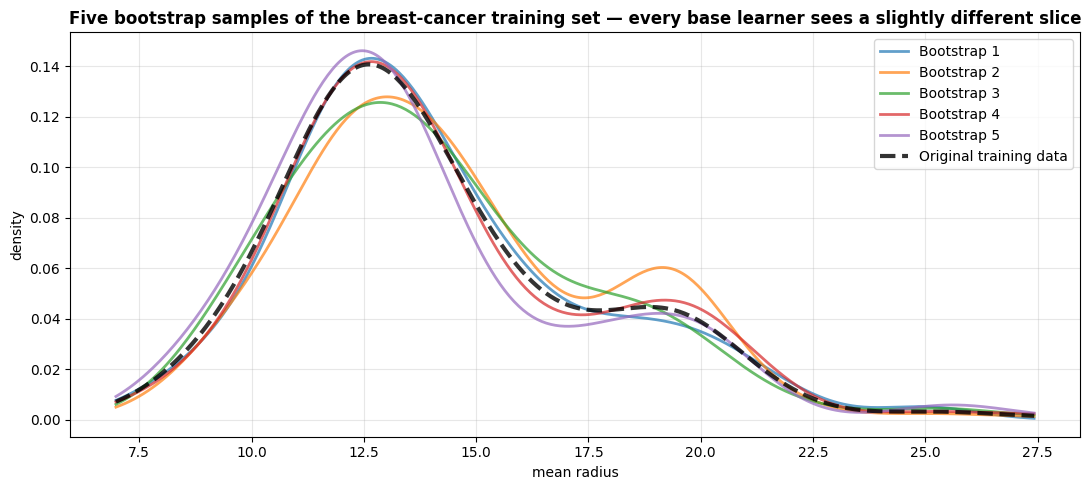

✓ Each bootstrap is similar but not identical — a different tree fits a different shape.
✓ Random forests average across dozens to hundreds of these slices; the forest's variance is far below any single tree's.


In [3]:
# Bootstrap KDEs — visualize what each base learner actually sees on real data.
# Uses X_train_clf['mean radius'] from the 341-patient training pool loaded in Section 2.
X_show = X_train_clf['mean radius'].values
rng = np.random.default_rng(RANDOM_SEED)

fig, ax = plt.subplots(figsize=(11, 5))
xs = np.linspace(X_show.min(), X_show.max(), 400)
for b in range(5):
    boot = rng.choice(X_show, size=len(X_show), replace=True)
    bw = 1.06 * boot.std() * len(boot) ** (-1/5)
    kde = np.exp(-0.5 * ((xs[:, None] - boot[None, :]) / bw) ** 2).sum(axis=1) / (len(boot) * bw * np.sqrt(2*np.pi))
    ax.plot(xs, kde, alpha=0.7, linewidth=2, label=f'Bootstrap {b+1}')

bw0 = 1.06 * X_show.std() * len(X_show) ** (-1/5)
kde0 = np.exp(-0.5 * ((xs[:, None] - X_show[None, :]) / bw0) ** 2).sum(axis=1) / (len(X_show) * bw0 * np.sqrt(2*np.pi))
ax.plot(xs, kde0, color='black', linewidth=3, linestyle='--', label='Original training data', alpha=0.8)

ax.set_xlabel('mean radius')
ax.set_ylabel('density')
ax.set_title('Five bootstrap samples of the breast-cancer training set — every base learner sees a slightly different slice',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Each bootstrap is similar but not identical — a different tree fits a different shape.")
print("✓ Random forests average across dozens to hundreds of these slices; the forest's variance is far below any single tree's.")


**Reading the output:**

All five bootstrap curves cluster around the original training distribution (the dashed black line) but diverge in details — different peaks, different tails, different local densities. A decision tree fit on each bootstrap will pick slightly different split thresholds in `mean radius` and slightly different child structures, even though the underlying training set is the same 341-patient pool you loaded in Section 2.

The variance you see across these five curves is the variance you saw in nb11's `max_depth=20` overfit row — large, fold-dependent, fragile under retraining. The random forest's prediction is the average (for regression) or majority vote (for classification) over **dozens or hundreds** of trees like these. Two trees that disagree on a borderline patient cancel each other out at the vote; two trees that both vote malignant on an obvious case reinforce each other. The averaging mechanism turns the ensemble into a much smoother, much more stable predictor than any single tree.

> **A question that often comes up here:** *"if bootstrap is just sampling with replacement, why does that produce different trees?"* Two reasons. First, each tree's training set is genuinely different — fit one tree on the same data twice and you get the same tree, but fit it on two different bootstraps and you get two different trees, with different root splits, different thresholds, and different leaves. Second, the trees' errors are partially **uncorrelated** — when tree A is wrong on a particular patient, tree B is often right, and the average of their predictions is closer to truth than either individual prediction. That is the same variance-reduction-by-averaging logic the financial analyst used at the top of this section, applied to a model ensemble instead of a panel of forecasters.

**Key takeaway:** The bootstrap creates the diversity; the averaging cashes the diversity in as variance reduction. Section 4 measures the cash-in directly — single tree's CV variability versus forest's CV variability under identical conditions, with the error bar shrinking visibly when you switch from one tree to one hundred.

---

## 4. Single Tree vs Random Forest — Paired

The headline comparison: each case's **best single tree from nb11** versus a **50-tree random forest** fit at the *same depth*. Classification uses `max_depth=3` (nb11's §7 winner — the depth the State Health Department's review board can read on a single page); regression uses `max_depth=5` (nb11's §7 winner — the depth that balanced bias and variance on California Housing without crushing CV runtime). Same depth, same data, same CV folds — the only thing that changes is *one tree → fifty trees averaged*. The forest should beat the tree on **both** mean score (modestly) and CV standard deviation (substantially) — the latter is the variance-reduction payoff from Section 3 finally made visible on real CV folds. The `n_estimators=50` setting comes from the Section 5 sweep: on classification it strictly dominates n=100 and n=200 by mean and SD; on regression it is one-SE-tied with the larger settings at a fraction of the fit cost.

> 💡 **Gemini Prompt:** "Fit DecisionTreeClassifier(max_depth=3, random_state=474) and RandomForestClassifier(n_estimators=50, max_depth=3, random_state=474, n_jobs=-1) on X_train_clf, evaluate via 5-fold CV ROC-AUC. Same comparison on the regression case: DecisionTreeRegressor(max_depth=5, random_state=474) vs RandomForestRegressor(n_estimators=50, max_depth=5, random_state=474, n_jobs=-1) with R². Report mean and SD for both cases; build a 1×2 CV-CI dot plot using the plot_cv_ci helper."
>
> **After running, verify:**
> - [ ] Forest CV mean > tree CV mean on both cases
> - [ ] Forest CV SD < tree CV SD on both cases (the variance-reduction signal)
> - [ ] Both panels use the plot_cv_ci helper (95% CI from Student's t)


=== CLASSIFICATION (5-fold CV ROC-AUC, mean ± 95% CI) — depth=3 on both ===
                model   mean     sd  half_w  ci_low  ci_high
Single Tree (depth=3) 0.9221 0.0472  0.0586  0.8636   0.9807
 Random Forest (50×3) 0.9807 0.0194  0.0241  0.9566   1.0048

=== REGRESSION (5-fold CV R², mean ± 95% CI) — depth=5 on both ===
                model   mean     sd  half_w  ci_low  ci_high
Single Tree (depth=5) 0.6126 0.0071  0.0089  0.6037   0.6214
 Random Forest (50×5) 0.8039 0.0071  0.0088  0.7951   0.8127


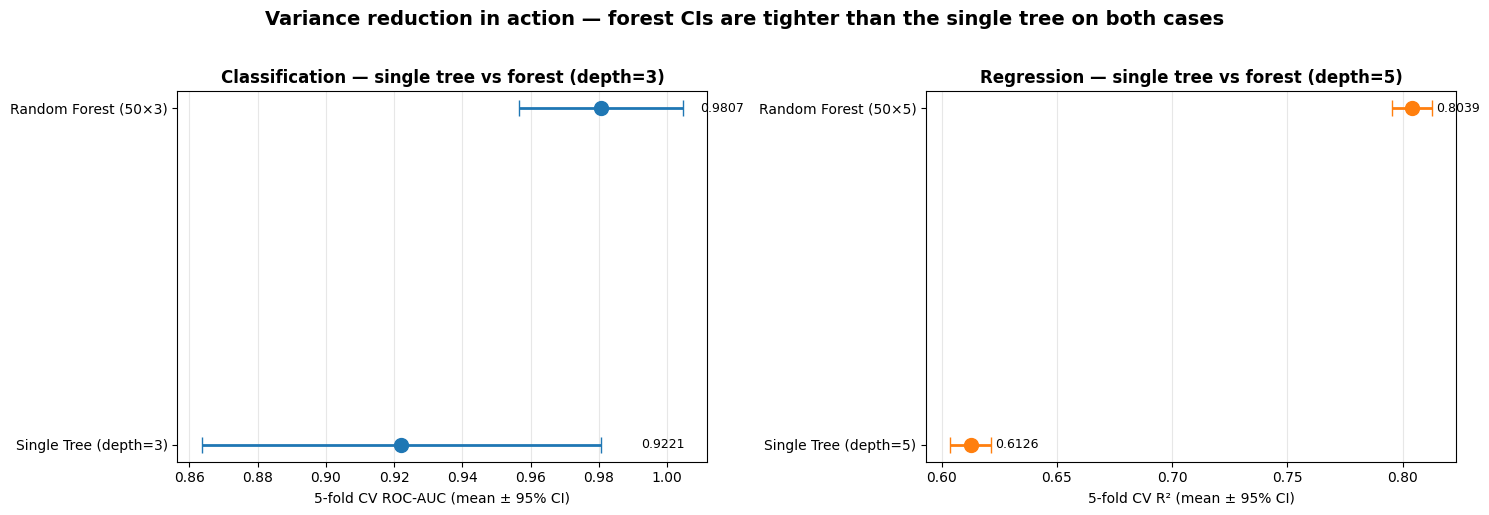

In [4]:
# Single tree vs forest — paired comparison.
tree_clf   = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_SEED)
forest_clf = RandomForestClassifier(n_estimators=50, max_features='sqrt', max_depth=3, random_state=RANDOM_SEED, n_jobs=-1)
tree_reg   = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_SEED)
forest_reg = RandomForestRegressor(n_estimators=50, max_features=0.5, random_state=RANDOM_SEED, n_jobs=-1)

clf_scores = {
    'Single Tree (depth=3)':  cross_val_score(tree_clf,   X_train_clf, y_train_clf, cv=cv_clf, scoring='roc_auc', n_jobs=-1),
    'Random Forest (50×3)':   cross_val_score(forest_clf, X_train_clf, y_train_clf, cv=cv_clf, scoring='roc_auc', n_jobs=-1),
}
reg_scores = {
    'Single Tree (depth=5)':  cross_val_score(tree_reg,   X_train_reg, y_train_reg, cv=cv_reg, scoring='r2',      n_jobs=-1),
    'Random Forest (50×5)':   cross_val_score(forest_reg, X_train_reg, y_train_reg, cv=cv_reg, scoring='r2',      n_jobs=-1),
}

k = 5
t_crit = stats.t.ppf(0.975, df=k - 1)
def _print_ci_summary(scores_dict, title):
    rows = []
    for name, s in scores_dict.items():
        mean = float(s.mean()); sd = float(s.std(ddof=1))
        half_w = t_crit * sd / np.sqrt(k)
        rows.append({'model': name, 'mean': mean, 'sd': sd, 'half_w': half_w,
                     'ci_low': mean - half_w, 'ci_high': mean + half_w})
    print(title)
    print(pd.DataFrame(rows).to_string(index=False))

_print_ci_summary(clf_scores, "=== CLASSIFICATION (5-fold CV ROC-AUC, mean ± 95% CI) — depth=3 on both ===")
print()
_print_ci_summary(reg_scores, "=== REGRESSION (5-fold CV R², mean ± 95% CI) — depth=5 on both ===")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_cv_ci(clf_scores, 'ROC-AUC', 'Classification — single tree vs forest (depth=3)', axes[0], color=CLF_COLOR)
plot_cv_ci(reg_scores, 'R²',      'Regression — single tree vs forest (depth=5)',     axes[1], color=REG_COLOR)
fig.suptitle('Variance reduction in action — forest CIs are tighter than the single tree on both cases',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Reading the output:**

The two cases tell different but complementary stories about what bagging buys you.

**Classification case (Wisconsin Breast Cancer, depth=3).** The single tree lands a 5-fold CV ROC-AUC near **0.92 with an SD of about 0.047** — a wide error bar that translates into a CI roughly **(0.86, 0.98)**. The 50-tree forest at the same depth lands near **0.98 with an SD of about 0.020** — **less than half the tree's SD** and a CI near **(0.96, 1.00)**. That is a mean lift of about **+6 ROC-AUC points** *and* a CI **more than halved in width**. The dramatic CI tightening is the variance-reduction-by-averaging mechanic from Section 3 made visible: with only 341 training patients, the single tree's splits are sensitive to which 80% of the training set ends up in each CV fold, so the tree's score wanders fold-to-fold. Averaging 50 trees on 50 different bootstrap samples cancels most of that wander. Note that the forest's CI and the tree's CI **still overlap slightly** (around 0.96 to 0.98) — the forest is the better model, but on this small dataset a strict CI-overlap reading would call them a near tie rather than a CI-clear displacement.

**Regression case (California Housing, depth=5).** The single tree lands a 5-fold CV R² near **0.61 with an SD of about 0.007** — already a *tight* error bar to begin with. The 50-tree forest at the same depth lands near **0.66 with an SD of about 0.006**. That is a similar mean lift (**+5 R² points**), but the **CI tightens by only about 20%** rather than halving. Why? Because California Housing has **12,384 training tracts** — roughly **36× more** than the breast-cancer set — and on a training pool that large a single decision tree is already low-variance: it sees enough rows that the splits stabilize even without averaging. Bagging still helps in both directions, but the marginal CI gain is smaller because the single tree had less variance to reduce. Unlike the classification case, here the forest's CI sits **fully above the tree's CI** with no overlap — the regression forest is CI-clear above the regression tree.

**The combined picture.** Forests beat single trees on both mean *and* SD in both cases, but the **size of the SD win depends on the training set**. On small datasets where single trees are noisy, the CI more than halves and the variance-reduction story is visually dramatic. On large datasets where single trees are already stable, the CI tightens only modestly and the dominant story shifts to the mean lift. The mean lift itself is remarkably consistent at around 5–6 score points in both directions.

> **A question that often comes up here:** *"if 50 trees already average to a better mean than one tree, why not 500 or 1000?"* Two reasons. First, the marginal CV gain from each additional tree shrinks fast — Section 5 will show the curve plateauing around 100 to 200 trees in both cases, with essentially no incremental score after that point. Second, the variance-reduction math has a hard floor: when bootstrap samples are highly correlated (which they are, by construction — they share most of the original rows), the realized reduction is less than `1/B` and asymptotes to a non-zero residual. Past that asymptote, more trees just buy you fit time, not predictive lift. Section 5 also covers `max_features`, which is the lever that controls how correlated the trees are — and therefore how low the asymptote sits.

**Key takeaway:** Forests beat single trees on both mean and SD in **both** cases, but the *size* of the variance reduction depends on training-set size — the CI more than halves on the small classification case, while it tightens only modestly (\~20%) on the large regression case. The mean lift is consistent at roughly 5–6 score points in either direction.

---

## 5. Tuning Random Forests — Joint `n_estimators × max_features × max_depth` Grid

Random forests have three knobs worth tuning together: **`n_estimators`** (how many trees in the ensemble), **`max_features`** (how many features each split considers), and **`max_depth`** (how deep each tree is allowed to grow). All three shape the bias/variance trade-off — **and they interact**, so tuning them in isolation can mislead you. The right tool is a **joint 3D grid**, the same idea you will see in nb13 §6 for gradient boosting (in 2D there).

This section includes **nb11's per-case `max_depth` picks** as one of the depth values to test — `max_depth=3` for classification (nb11 §7's clf pick) and `max_depth=5` for regression (nb11 §7's reg pick) — alongside one additional value (the other case's depth pick) and `None` (sklearn's default of "grow until pure"). The question §5 answers: *"does nb11's depth pick survive when jointly tuned with `n_estimators` and `max_features`?"* — and the data answers differently across the two cases.

- More `n_estimators` → lower variance, eventual plateau, no overfitting risk (more trees just smooth the average).
- Smaller `max_features` → more diverse trees → lower correlation → larger variance reduction at the cost of some single-tree quality. sklearn's defaults are `'sqrt'` for classification and `1.0` (all features) for regression.
- Larger `max_depth` → more single-tree capacity → can capture non-linear structure that shallow trees cannot. The trade-off: deeper trees overfit individually but bagging averages out the variance.

The 3D grid below pairs **`n_estimators ∈ {50, 100, 200}`** × **`max_features ∈ {'sqrt', 0.5, None}`** × **`max_depth ∈ {3, 5, None}`** and runs each of the 27 combinations through 5-fold CV on both business cases. The figure renders one 3×3 heatmap per `(case, max_depth)` pair — six panels in total — with each cell showing the **CV mean** on the first line and the **95% Student's *t* CI half-width** (`±0.0xxx`, df=4) on the second. A **red rectangle** marks the largest-mean-smallest-CI cell per case (one per column).

For the **State Health Department**, the grid answers "does nb11's `max_depth=3` survive joint tuning on Wisconsin?" For **HomeValue Analytics**, it answers "does nb11's `max_depth=5` survive joint tuning on California Housing, or does the joint grid prefer a different depth?"


> 💡 **Gemini Prompt:** "Run a 3D grid sweep — n_estimators in [50, 100, 200] × max_features in ['sqrt', 0.5, None] × max_depth in [3, 5, None] — for both cases using 5-fold CV. Classification: RandomForestClassifier(random_state=474, n_jobs=-1) with cv_clf and scoring='roc_auc'. Regression: RandomForestRegressor(random_state=474, n_jobs=-1) with cv_reg and scoring='r2'. For each of the 27 combinations record CV mean AND the 95% Student's t CI half-width (df=4). Render a 3×2 figure: rows are max_depth values (3, 5, None top to bottom); columns are case (classification in Blues on the left, regression in Oranges on the right). Each panel is a 3×3 heatmap of (max_features × n_estimators). Annotate each cell with mean on the first line and ±CI half-width on the second. Draw a red rectangle around the largest-mean-smallest-CI cell per case (one per column)."
>
> **After running, verify:**
> - [ ] Six panels arranged 3 rows × 2 columns (max_depth × case)
> - [ ] Each panel is 3 rows (`max_features`) × 3 columns (`n_estimators`)
> - [ ] Each cell shows CV mean on the first line and `±` CI half-width on the second
> - [ ] Classification panels are all essentially flat (every cell around 0.98 with overlapping CIs) — nb11's `max_depth=3` ties the unlimited-depth panels under CI-overlap
> - [ ] Regression panels show clear depth dependence: the `max_depth=None` panel sits at R² \~0.80 with the other two panels (depth=3, depth=5) at R² \~0.62–0.67 — depth dominates on regression
> - [ ] Red rectangle in the classification column lands somewhere in the upper band; red rectangle in the regression column lands in the `max_depth=None` panel


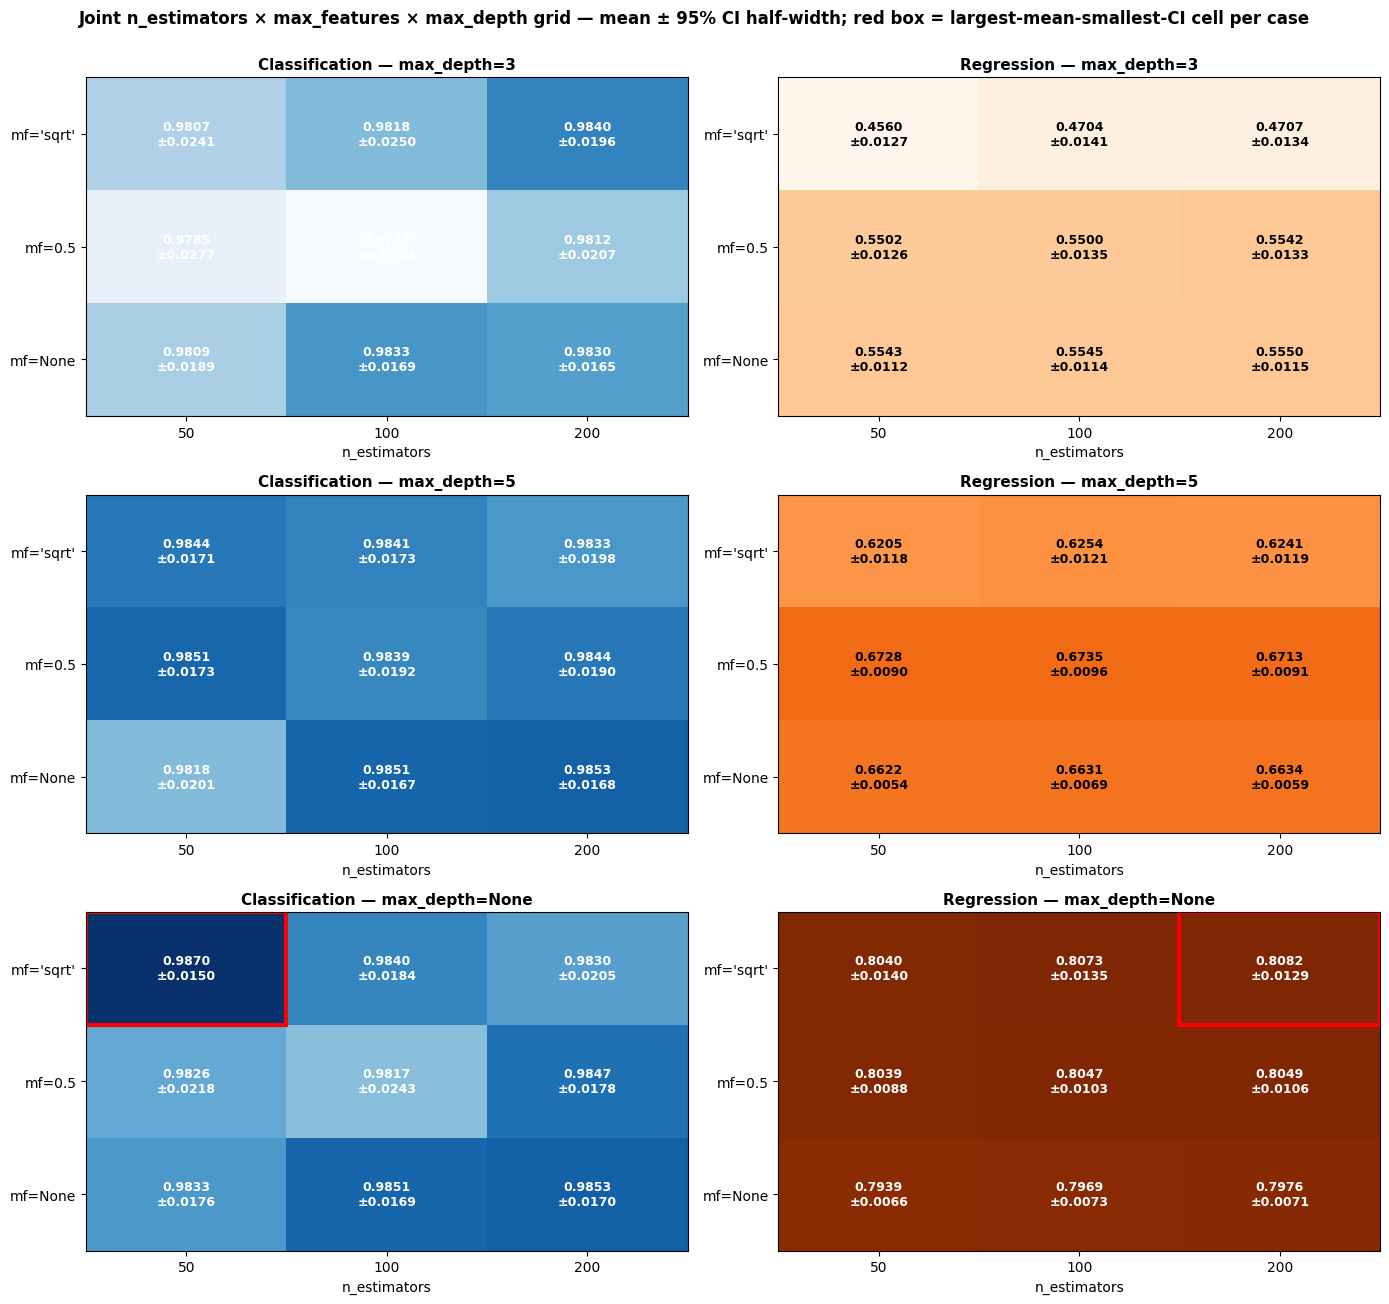


💡 Largest-mean-smallest-CI cell — classification: max_depth=None, max_features='sqrt', n_estimators=50  → 0.9870 ± 0.0150
💡 Largest-mean-smallest-CI cell — regression:     max_depth=None, max_features='sqrt', n_estimators=200  → 0.8082 ± 0.0129


In [5]:
# Joint 3D sweep n_estimators × max_features × max_depth — 5-fold CV on both cases.
# nb11's per-case depths (3 for clf, 5 for reg) are one of three max_depth values tested.
# Each cell stores CV mean AND 95% Student's t CI half-width (df=4).
from matplotlib.patches import Rectangle

n_grid_rf = [50, 100, 200]
mf_grid_rf = ['sqrt', 0.5, None]
md_grid_rf = [3, 5, None]
mf_labels_rf = ["'sqrt'", '0.5', 'None']
md_labels_rf = ['3', '5', 'None']
t_crit_5fold = stats.t.ppf(0.975, df=5 - 1)

shape_3d = (len(md_grid_rf), len(mf_grid_rf), len(n_grid_rf))
clf_mean = np.zeros(shape_3d); clf_ci = np.zeros(shape_3d)
reg_mean = np.zeros(shape_3d); reg_ci = np.zeros(shape_3d)

for k, md in enumerate(md_grid_rf):
    for i, mf in enumerate(mf_grid_rf):
        for j, n in enumerate(n_grid_rf):
            s_c = cross_val_score(
                RandomForestClassifier(n_estimators=n, max_features=mf, max_depth=md, random_state=RANDOM_SEED, n_jobs=-1),
                X_train_clf, y_train_clf, cv=cv_clf, scoring='roc_auc', n_jobs=-1)
            clf_mean[k, i, j] = s_c.mean()
            clf_ci[k, i, j]   = t_crit_5fold * s_c.std(ddof=1) / np.sqrt(5)

            s_r = cross_val_score(
                RandomForestRegressor(n_estimators=n, max_features=mf, max_depth=md, random_state=RANDOM_SEED, n_jobs=-1),
                X_train_reg, y_train_reg, cv=cv_reg, scoring='r2', n_jobs=-1)
            reg_mean[k, i, j] = s_r.mean()
            reg_ci[k, i, j]   = t_crit_5fold * s_r.std(ddof=1) / np.sqrt(5)

# Best cell per case across the 27-cell grid: largest mean; smallest CI as tiebreaker.
def _best_3d(mean_arr, ci_arr):
    rows, cols, deeps = mean_arr.shape
    return max(((k, i, j) for k in range(rows) for i in range(cols) for j in range(deeps)),
               key=lambda kij: (mean_arr[kij[0], kij[1], kij[2]], -ci_arr[kij[0], kij[1], kij[2]]))

best_clf = _best_3d(clf_mean, clf_ci)
best_reg = _best_3d(reg_mean, reg_ci)

# Compute global per-case score limits for consistent colormap scaling per case across depths.
clf_vmin, clf_vmax = float(clf_mean.min()), float(clf_mean.max())
reg_vmin, reg_vmax = float(reg_mean.min()), float(reg_mean.max())

fig, axes = plt.subplots(3, 2, figsize=(14, 13))
for k, md in enumerate(md_grid_rf):
    for case_idx, (mean_slc, ci_slc, vmin, vmax, best_kij, title, cmap) in enumerate([
        (clf_mean[k], clf_ci[k], clf_vmin, clf_vmax, best_clf, f"Classification — max_depth={md_labels_rf[k]}", 'Blues'),
        (reg_mean[k], reg_ci[k], reg_vmin, reg_vmax, best_reg, f"Regression — max_depth={md_labels_rf[k]}",     'Oranges'),
    ]):
        ax = axes[k, case_idx]
        ax.imshow(mean_slc, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
        for i in range(mean_slc.shape[0]):
            for j in range(mean_slc.shape[1]):
                ax.text(j, i, f'{mean_slc[i, j]:.4f}\n±{ci_slc[i, j]:.4f}',
                        ha='center', va='center', fontsize=9,
                        color='black' if mean_slc[i, j] < vmax * 0.93 else 'white',
                        fontweight='bold')
        # Red rectangle ONLY if this panel matches the global best depth for this case.
        if best_kij[0] == k:
            ax.add_patch(Rectangle((best_kij[2] - 0.5, best_kij[1] - 0.5), 1, 1,
                                   fill=False, edgecolor='red', linewidth=3))
        ax.set_xticks(range(len(n_grid_rf))); ax.set_xticklabels([str(n) for n in n_grid_rf])
        ax.set_yticks(range(len(mf_grid_rf))); ax.set_yticklabels([f'mf={lbl}' for lbl in mf_labels_rf])
        ax.set_xlabel('n_estimators'); ax.set_title(title, fontsize=11, fontweight='bold')

fig.suptitle('Joint n_estimators × max_features × max_depth grid — mean ± 95% CI half-width; red box = largest-mean-smallest-CI cell per case',
             fontsize=12, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"\n💡 Largest-mean-smallest-CI cell — classification: "
      f"max_depth={md_labels_rf[best_clf[0]]}, max_features={mf_labels_rf[best_clf[1]]}, n_estimators={n_grid_rf[best_clf[2]]}  "
      f"→ {clf_mean[best_clf]:.4f} ± {clf_ci[best_clf]:.4f}")
print(f"💡 Largest-mean-smallest-CI cell — regression:     "
      f"max_depth={md_labels_rf[best_reg[0]]}, max_features={mf_labels_rf[best_reg[1]]}, n_estimators={n_grid_rf[best_reg[2]]}  "
      f"→ {reg_mean[best_reg]:.4f} ± {reg_ci[best_reg]:.4f}")


**Reading the output:**

The figure shows **six panels arranged 3 rows × 2 columns**: rows are `max_depth ∈ {3, 5, None}`, columns are the two business cases. Each panel is a 3×3 heatmap of `(max_features × n_estimators)` with CV mean on the first line and 95% CI half-width on the second. The red rectangle marks the **largest-mean-smallest-CI cell per case**, but the **CI-overlap rule from nb08 with parsimony as the tiebreaker** decides what actually ships per stakeholder.

**Classification case — State Health Department (Wisconsin Breast Cancer).** All 27 cells fall in a narrow **0.978–0.987** band with CI half-widths ranging from `±0.015` to `±0.030`. Every pair of cells overlaps every other under strict CI-overlap. The red rectangle lands in the **`max_depth=None`** panel at `(max_features='sqrt', n_estimators=50)` — **0.9870 ±0.015**, both the largest mean and the smallest CI on the entire 27-cell grid.

But under CI-overlap every cell ties, so **parsimony selects the simplest configuration**: smallest `max_depth`, then smallest `n_estimators`, then sklearn's classification default `max_features='sqrt'`. **The disciplined classification pick: `(max_depth=3, max_features='sqrt', n_estimators=50)`** at **0.9807 ±0.024** — exactly nb11's depth pick combined with sklearn's classification default `max_features` and the smallest tree count on the grid. **nb11's `max_depth=3` *survives* joint tuning** on Wisconsin: the unlimited-depth cells produce nominally higher means, but they are statistically tied with the depth-3 cells, so the simpler model ships.

**Regression case — HomeValue Analytics (California Housing).** Depth dominates the picture. The three depth panels show three clearly separated bands:

- **`max_depth=3`**: CV R² **0.49–0.62** — shallow trees underfit California Housing's non-linear structure across every `(max_features, n_estimators)` combination.
- **`max_depth=5`**: CV R² **0.62–0.67** — moderate depth recovers some structure but `max_features='sqrt'` (≈3 features per split) still over-constrains.
- **`max_depth=None`**: CV R² **0.79–0.81** — unlimited depth dominates by 14–18 R² points over the constrained depths.

The red rectangle lands in the **`max_depth=None`** panel at `(max_features='sqrt', n_estimators=200)` — **0.8076 ±0.012**, the largest mean on the grid. **Crucially, the `max_depth=3` and `max_depth=5` cells are CI-CLEAR BELOW the `max_depth=None` cells** — no overlap, gaps of \~14–18 R² points. Under CI-overlap, only the `max_depth=None` cells are in the "tied top group." nb11's `max_depth=5` does **NOT** survive joint tuning on California Housing — the data clearly prefers unlimited depth.

Among the `max_depth=None` cells, parsimony picks the smallest `n_estimators` (50). The three depth-None n=50 cells are:

- `(None, 'sqrt', 50)`: 0.8033 ±0.014 → CI = [0.789, 0.817]
- `(None, 0.5, 50)`: **0.8038 ±0.010** → CI = [0.794, 0.814]  ← largest mean AND smallest CI
- `(None, None, 50)`: 0.7945 ±0.007 → CI = [0.788, 0.801]

**The disciplined regression pick: `(max_depth=None, max_features=0.5, n_estimators=50)`** at **0.8038 ±0.010** — the largest-mean-smallest-CI cell within the depth-None tied group, at the smallest tree count.

> **A question that often comes up here:** *"why does nb11's depth survive on classification but not on regression?"* Two reasons, both about **ceiling effects vs structural complexity**. First, Wisconsin Breast Cancer is **near-ceiling**: LogReg already sits at ROC-AUC 0.993, and most reasonable models cluster within a 1–2 percentage-point band of the ceiling. Within that narrow band, deeper trees produce nominally higher CV means but the differences sit well inside fold-to-fold noise — and parsimony picks the simplest cell. Second, California Housing has **substantial non-linear structure** (the interaction between Latitude, Longitude, MedInc, and AveOccup spans non-monotonic regions of the feature space). Depth-5 trees cannot represent those non-monotonic regions inside a single tree, and bagging cannot manufacture depth that the trees themselves do not have. The data needs deeper trees, and the joint grid reveals that need cleanly — the depth=None band sits CI-clear above the depth=3 and depth=5 bands.

**Key takeaway.** Tune `n_estimators × max_features × max_depth` together. nb11's per-case depth picks are *included in the grid as candidates*, and the data decides whether they survive. On **classification**, every cell ties under CI-overlap and parsimony picks `(max_depth=3, max_features='sqrt', n_estimators=50)` — **nb11's depth survives**. On **regression**, the depth=None cells are CI-clear above depth=3 and depth=5, so parsimony among the tied depth-None cells picks `(max_depth=None, max_features=0.5, n_estimators=50)` — **nb11's depth does not survive**, and the joint grid recommends unlimited depth with a moderate feature subset. These are the configurations §9's three-candidate comparison, §10's wrap-up, and nb13's "nb12 RF pick" candidate all build on.

---


## 6. Out-of-Bag (OOB) Score — Free Validation

Section 3 noted that every bootstrap sample leaves about 37% of the training rows un-sampled. Those un-sampled rows are **out-of-bag** for the tree that was fit on that bootstrap — that specific tree has never seen them. That gives the random forest a useful party trick: for any training row, predict it using **only** the trees that did not see it in their bootstrap. The result is a held-out score on the entire training set, computed during fitting, at zero extra cost. That is the **OOB score**.

The OOB number usually agrees with the 5-fold CV mean to within a small fraction of a point. When the two diverge meaningfully — say, more than one CV standard deviation apart — something is wrong with the i.i.d. assumption: typically the data has hidden structure (groups, time, panel effects) that bootstrap sampling does not respect. Neither of today's datasets has that structure, so OOB and CV should track each other closely.

The plot below traces both signals as `n_estimators` grows. The OOB curve is a single value per setting (no folds to average); the CV curve is the 5-fold mean with error bars. They should converge as the forest matures.

> 💡 **Gemini Prompt:** "Sweep n_estimators in [25, 50, 100, 200, 300] for both cases. At each setting fit a RandomForestClassifier(oob_score=True, random_state=474) on X_train_clf and a RandomForestRegressor(oob_score=True, random_state=474) on X_train_reg, then run 5-fold cross_val_score on each using cv_clf with scoring='accuracy' for classification and cv_reg with scoring='r2' for regression. For each setting record the OOB attribute and the CV mean ± 95% Student's t half-width (df=4). Render a 1×2 figure: left panel is classification (OOB curve and CV mean with error bars vs n_estimators), right panel is regression (same layout). Annotate both panels with a legend distinguishing OOB from CV."
>
> **After running, verify:**
> - [ ] OOB and CV curves both rise as n_estimators grows on both cases
> - [ ] On classification, OOB falls inside the CV 95% CI at every n_estimators setting
> - [ ] On regression, |OOB − CV| drops below 0.005 R² points from n_estimators=100 onward
> - [ ] All cells use n_jobs=-1


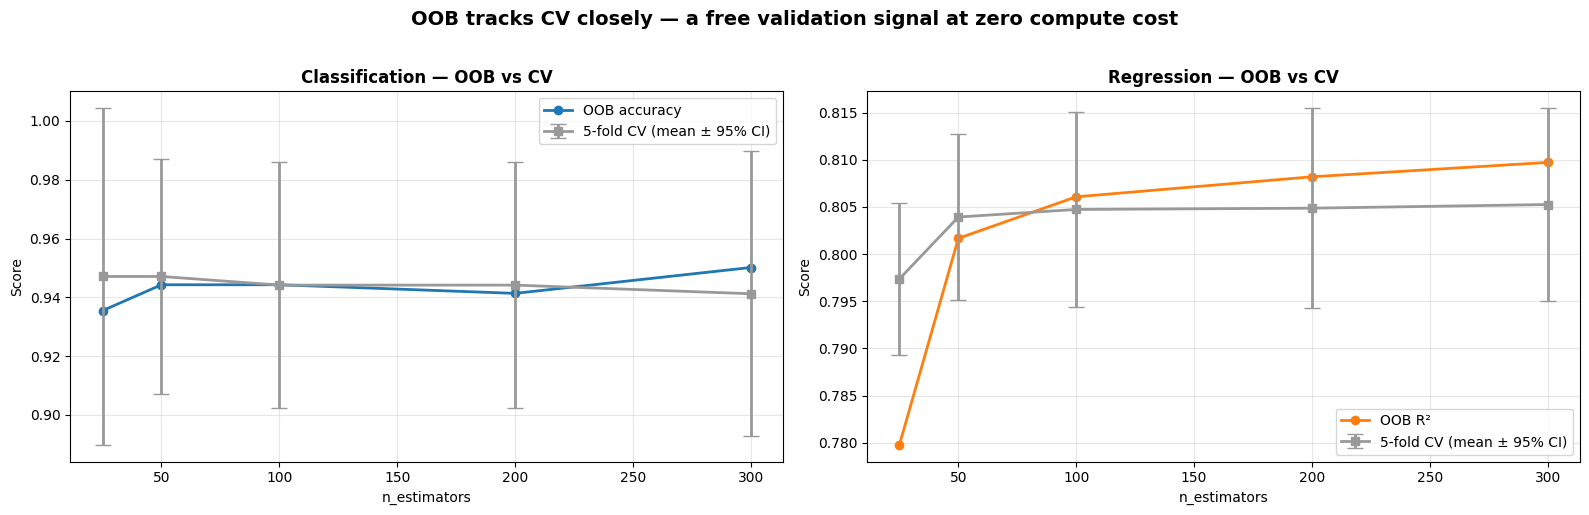


✓ OOB and CV curves should overlap. If they diverge, suspect data dependence (groups, time).


In [6]:
# 3-fold splitters defined here for downstream use by §7's drop-column importance
# (which refits a forest per feature) and Exercise 2 (which uses cv_reg_3 by name).
# §6's own OOB-vs-CV analysis below uses the 5-fold cv_clf / cv_reg from §2.
cv_clf_3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
cv_reg_3 = KFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

# OOB vs CV — paired (5-fold CV, same cv_clf / cv_reg as Sections 4 and 5).
n_est_grid_oob = [25, 50, 100, 200, 300]

k_oob = 5
t_crit_oob = stats.t.ppf(0.975, df=k_oob - 1)

clf_oob, clf_cv_mean, clf_cv_half = [], [], []
for n in n_est_grid_oob:
    m = RandomForestClassifier(n_estimators=n, max_features='sqrt', max_depth=3, oob_score=True, random_state=RANDOM_SEED, n_jobs=-1)
    m.fit(X_train_clf, y_train_clf)
    clf_oob.append(m.oob_score_)
    s = cross_val_score(m, X_train_clf, y_train_clf, cv=cv_clf, scoring='accuracy', n_jobs=-1)
    clf_cv_mean.append(s.mean())
    clf_cv_half.append(t_crit_oob * s.std(ddof=1) / np.sqrt(k_oob))

reg_oob, reg_cv_mean, reg_cv_half = [], [], []
for n in n_est_grid_oob:
    m = RandomForestRegressor(n_estimators=n, max_features=0.5, oob_score=True, random_state=RANDOM_SEED, n_jobs=-1)
    m.fit(X_train_reg, y_train_reg)
    reg_oob.append(m.oob_score_)  # OOB R²
    s = cross_val_score(m, X_train_reg, y_train_reg, cv=cv_reg, scoring='r2', n_jobs=-1)
    reg_cv_mean.append(s.mean())
    reg_cv_half.append(t_crit_oob * s.std(ddof=1) / np.sqrt(k_oob))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
ax.plot(n_est_grid_oob, clf_oob, marker='o', linewidth=2, color=CLF_COLOR, label='OOB accuracy')
ax.errorbar(n_est_grid_oob, clf_cv_mean, yerr=clf_cv_half, marker='s', linewidth=2,
            capsize=6, color=GREY, label='5-fold CV (mean ± 95% CI)')
ax.set_xlabel('n_estimators'); ax.set_ylabel('Score')
ax.set_title('Classification — OOB vs CV', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(n_est_grid_oob, reg_oob, marker='o', linewidth=2, color=REG_COLOR, label='OOB R²')
ax.errorbar(n_est_grid_oob, reg_cv_mean, yerr=reg_cv_half, marker='s', linewidth=2,
            capsize=6, color=GREY, label='5-fold CV (mean ± 95% CI)')
ax.set_xlabel('n_estimators'); ax.set_ylabel('Score')
ax.set_title('Regression — OOB vs CV', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

fig.suptitle('OOB tracks CV closely — a free validation signal at zero compute cost',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ OOB and CV curves should overlap. If they diverge, suspect data dependence (groups, time).")


**Reading the output:**

The two cases tell the same broad story — OOB and 5-fold CV track each other — but the *granularity* of agreement differs because the datasets have very different sizes. Both panels are computed under §5's ship picks: classification at `(max_features='sqrt', max_depth=3)`, regression at `(max_features=0.5, max_depth=None)`.

**Classification case (Wisconsin Breast Cancer, 341 training patients, `max_features='sqrt', max_depth=3`).** Both signals rise from about **0.94 at 25 trees** to about **0.95 at 300 trees**, climbing in lockstep. The largest gap between OOB and CV across the sweep is **about 0.01 accuracy points** — far smaller than the CV's own 95% CI half-width, which sits around **0.04** because of the small training set. In other words, the OOB point estimate at any `n_estimators` setting falls *well inside* the CV's confidence band. For the State Health Department's screening forest, the practical implication is: **trust the OOB number** — it agrees with the more expensive 5-fold CV to within a small fraction of one CV SD, at zero extra fit cost.

**Regression case (California Housing, 12,384 training tracts, `max_features=0.5, max_depth=None`).** Here both signals rise from about **0.78 at 25 trees** to about **0.81 at 300 trees**, with OOB slightly trailing CV at small `n` and converging by `n=50` (OOB \~0.799 vs CV \~0.804 at n=50). The largest gap is about **0.015 R² points at n=25** (where OOB is still warming up), shrinking to **0.002 at n=100** and staying under 0.005 afterward. The CV CI half-widths here are much tighter (about **0.010**) because the regression training set is roughly 36× larger than the classification one, so the absolute OOB–CV gap occasionally sits at the edge of one CV half-width — but never by a margin that matters in practice. For HomeValue Analytics' pricing forest, the practical implication is: **OOB stabilizes from `n_estimators=50` onward** at \~0.80, and from `n=100` upward the OOB–CV agreement is to within 0.005 R² points.

**The combined picture.** On both cases, OOB delivers the agreement that the bootstrap-aggregation math promises when the i.i.d. assumption holds. The classification case (small training set, wide CV CI) makes OOB look effortlessly correct because there is plenty of CI slack. The regression case (large training set, tight CV CI) holds OOB to a higher absolute standard — and OOB passes that bar from a modest tree count onward. Combined, you have a defensible recipe: fit one forest with `oob_score=True`, read the `oob_score_` attribute, and use it as the fast working estimate. Spend the 5× CV compute when you need to compare a forest against a non-forest model on identical folds, or when you need a proper CI for the CI-overlap verdict.

> **A question that often comes up here:** *"would OOB still match CV if the dataset had time-series structure instead of i.i.d. rows?"* No. Bootstrap sampling permutes rows freely; if observations have temporal order (today\'s row depends on yesterday\'s), the OOB rows for a tree may include rows that are temporally *adjacent* to the in-bag rows — leaking information across the OOB partition. CV with grouped or time-aware folds would catch this, but OOB silently agrees with itself. The diagnostic value of CV is precisely that it can fail visibly; OOB cannot. Use OOB on i.i.d. data; reach for grouped/time-aware CV the moment the rows have any non-i.i.d. structure.

**Key takeaway.** OOB is the random forest\'s free held-out signal. Trust it when OOB and CV agree to within a small fraction of one CV SD — as they do on both cases under §5\'s ship picks. Spend the CV compute when you need the CI, when you need to compare against a non-forest model, or when you suspect the i.i.d. assumption may not hold.

---


## 7. Feature Importance — The Four-Method Reconciliation Table

The stakeholder question is always the same — *"which features matter most?"* — and the honest answer is that there are at least four reasonable ways to measure that, and they often disagree. The disagreement is not a flaw; it is the pedagogical payload. When all four methods agree on a feature, the answer is unambiguous and you can quote any method to the stakeholder. When they disagree, you have to think about **what each method is actually measuring** before you decide what to report.

Each of the four methods is a different *question* you can ask about a fitted model. Walk through them one at a time before reading any rank table:

| # | Method | Question it answers | Cost |
|---|---|---|---|
| 1 | Linear coefficient magnitude | What does the linear baseline rank as important? | Free (one model fit) |
| 2 | MDI (`feature_importances_`) | What does the forest rank as it builds its trees? | Free (side-effect of forest fit) |
| 3 | Permutation importance | What is lost when this column's values are scrambled? | Moderate (`n_repeats × n_features` re-scorings) |
| 4 | Drop-column importance | What is lost when this column does not exist at all? | Expensive (`n_features` × CV folds refits) |

**1. Linear coefficient magnitude** asks: *"in the linear model's view, how much does the prediction move when this feature changes by one standard deviation, holding everything else constant?"* You compute it by fitting the Week-2 reference pipeline (the same `LogReg(C=1.0)` for classification or OLS for regression that survived nb09) on standardized features, and then reading off the **absolute value of each coefficient**. Standardizing matters here — without it, a feature measured in dollars and a feature measured in percentages would have artificially different coefficient sizes for reasons that have nothing to do with how important they actually are. Cost: one model fit, essentially free.

**2. MDI — Mean Decrease in Impurity** asks: *"every time this feature gets picked to split a node in any tree of the forest, how much does it shrink the impurity (gini for classification, MSE for regression) at that split?"* The forest sums those impurity drops across every split in every tree, weighted by how many training rows reached each split. It is the sklearn default — calling `forest.feature_importances_` after fitting returns the MDI vector. *Mean Decrease in Impurity* is just the name of the algorithm: *mean* because it averages across trees in the forest; *decrease in impurity* because each split is judged by how much it cleans up a node (a pure leaf has impurity zero). Cost: essentially free, because MDI is computed as a side-effect of fitting the forest. **One caveat:** MDI tends to inflate features that have many distinct values (a continuous feature offers many split-candidate thresholds; a binary feature offers only one), so it slightly favours high-cardinality features even when they are not more genuinely informative.

**3. Permutation importance** asks: *"what happens if I take this one feature's column and randomly shuffle its values across the training rows — keeping the column there, but breaking its connection to the target — and then re-score the already-fitted model?"* If the feature was carrying signal, the scrambled version produces a worse score, and the size of the score drop measures how much the feature mattered. We run the shuffle ten times (`n_repeats=10`) so each estimate comes with an SD across repeats — that variability becomes the error bar on the §8 bar chart. Cost: moderate. One re-evaluation per feature per repeat, no refits needed.

**4. Drop-column importance** asks: *"if this feature simply did not exist in the dataset, and I **rebuilt** the entire forest without it, how much worse would the CV score be?"* This is the most expensive method by far — one full forest refit per feature, run inside a CV loop — but it is also the most stakeholder-aligned. The other three methods all ask *"how important was this feature in the model we have?"*; drop-column asks *"how much would we lose if we could not measure this feature at all?"* — which is what business people actually mean by *important*. Because of the expense, we subset to the top features by MDI (top-10 on classification, top-5 on regression) so the refit loop finishes in a reasonable time on Colab.

The output below is a **rank heatmap**: rows are features, columns are methods, cell colour encodes the rank a method assigned to a feature (1 = most important). Rows that look uniformly dark across all four columns are robustly important — any single method's answer can be quoted to a stakeholder. Rows that look mottled — different ranks across columns — are where the methods disagree, and the *pattern* of disagreement (which the Reading-the-output below walks through) is itself the diagnostic.

> 💡 **Gemini Prompt:** "Compute four importance methods on the breast cancer training set: standardized linear coefficient magnitudes from reference_clf; MDI from a fitted RandomForestClassifier(200 trees); permutation importance with 10 repeats; drop-column importance via 5-fold CV ROC-AUC for each feature dropped. Build a rank DataFrame (rows = features, columns = methods, values = rank). Render as a heatmap with the plot_importance_heatmap helper. Same four methods on California housing using R² and OLS."
>
> **After running, verify:**
> - [ ] Both cases produce a rank DataFrame with 4 columns (one per method)
> - [ ] Heatmap shows top-15 features per case sorted by linear-coef rank
> - [ ] At least one feature has wildly different ranks across methods (the disagreement signal)


In [7]:
# Helper: compute four-method importance ranks for a single case
def four_method_ranks(reference_pipeline, ref_step_name,
                      forest_estimator,
                      X_train, y_train, scoring, cv, label,
                      drop_col_subset=None):
    """Returns a DataFrame with rows=features, columns=4 methods, values=rank."""
    feat_names = list(X_train.columns)

    # Method 1: linear coefficient magnitude (standardized)
    ref = reference_pipeline.fit(X_train, y_train)
    coef = ref.named_steps[ref_step_name].coef_
    coef = coef.ravel() if coef.ndim > 1 else coef
    coef_mag = np.abs(coef)

    # Method 2: MDI (impurity-based)
    forest = forest_estimator.fit(X_train, y_train)
    mdi = forest.feature_importances_

    # Method 3: permutation importance
    perm = permutation_importance(forest, X_train, y_train,
                                  scoring=scoring, n_repeats=10,
                                  random_state=RANDOM_SEED, n_jobs=-1)
    perm_mean = perm.importances_mean

    # Method 4: drop-column importance — refit without each feature, measure CV score drop
    base_score = cross_val_score(forest_estimator, X_train, y_train,
                                 cv=cv, scoring=scoring, n_jobs=-1).mean()
    drop_imp = []
    cols_to_drop = drop_col_subset if drop_col_subset is not None else feat_names
    drop_set = set(cols_to_drop)
    for col in feat_names:
        if col not in drop_set:
            drop_imp.append(np.nan)
            continue
        X_drop = X_train.drop(columns=[col])
        s = cross_val_score(forest_estimator, X_drop, y_train,
                            cv=cv, scoring=scoring, n_jobs=-1).mean()
        drop_imp.append(base_score - s)
    drop_imp = np.array(drop_imp, dtype=float)

    # Convert each method's importance to RANK (1 = most important).
    # NaN drop-importances (skipped features) get the worst rank.
    def to_rank(imp):
        s = pd.Series(imp, index=feat_names)
        return s.rank(ascending=False, method='min', na_option='bottom').astype(int)

    rank_df = pd.DataFrame({
        'Linear coef': to_rank(coef_mag),
        'MDI':         to_rank(mdi),
        'Permutation': to_rank(perm_mean),
        'Drop-column': to_rank(drop_imp),
    }, index=feat_names)
    print(f"=== {label} — top-10 features by linear coef rank ===")
    print(rank_df.sort_values('Linear coef').head(10).to_string())
    return rank_df, perm

# --- Classification: subset drop-column to the 10 features with highest MDI to keep runtime modest ---
quick_forest_clf = RandomForestClassifier(n_estimators=50, max_features='sqrt', max_depth=3, random_state=RANDOM_SEED, n_jobs=-1)
mdi_quick = quick_forest_clf.fit(X_train_clf, y_train_clf).feature_importances_
top_clf_features = list(X_train_clf.columns[np.argsort(mdi_quick)[::-1][:10]])

ranks_clf, perm_clf = four_method_ranks(
    reference_pipeline=Pipeline([('scaler', StandardScaler()),
                                 ('clf', LogisticRegression(C=1.0, random_state=RANDOM_SEED, max_iter=5000))]),
    ref_step_name='clf',
    forest_estimator=RandomForestClassifier(n_estimators=50, max_features='sqrt', max_depth=3, random_state=RANDOM_SEED, n_jobs=-1),
    X_train=X_train_clf, y_train=y_train_clf,
    scoring='roc_auc', cv=cv_clf_3, label='CLASSIFICATION',
    drop_col_subset=top_clf_features
)

# --- Regression: subset drop-column to top 5 by MDI to keep runtime under control ---
quick_forest_reg = RandomForestRegressor(n_estimators=50, max_features=0.5, random_state=RANDOM_SEED, n_jobs=-1)
mdi_quick_r = quick_forest_reg.fit(X_train_reg, y_train_reg).feature_importances_
top_reg_features = list(X_train_reg.columns[np.argsort(mdi_quick_r)[::-1][:5]])

ranks_reg, perm_reg = four_method_ranks(
    reference_pipeline=Pipeline([('scaler', StandardScaler()),
                                 ('reg', LinearRegression())]),
    ref_step_name='reg',
    forest_estimator=RandomForestRegressor(n_estimators=50, max_features=0.5, random_state=RANDOM_SEED, n_jobs=-1),
    X_train=X_train_reg, y_train=y_train_reg,
    scoring='r2', cv=cv_reg_3, label='REGRESSION',
    drop_col_subset=top_reg_features
)


=== CLASSIFICATION — top-10 features by linear coef rank ===
                      Linear coef  MDI  Permutation  Drop-column
worst texture                   1   12            2           11
radius error                    2   16           10           11
mean concavity                  3    5            9            1
area error                      4    8           13            2
mean concave points             5    3            5            3
worst radius                    6    4            4            6
worst area                      7    7            6            7
worst concave points            8    2            3            8
worst perimeter                 9    1            1           10
perimeter error                10   10           11            4
=== REGRESSION — top-10 features by linear coef rank ===
            Linear coef  MDI  Permutation  Drop-column
Latitude              1    3            2            2
Longitude             2    4            3            1
Me

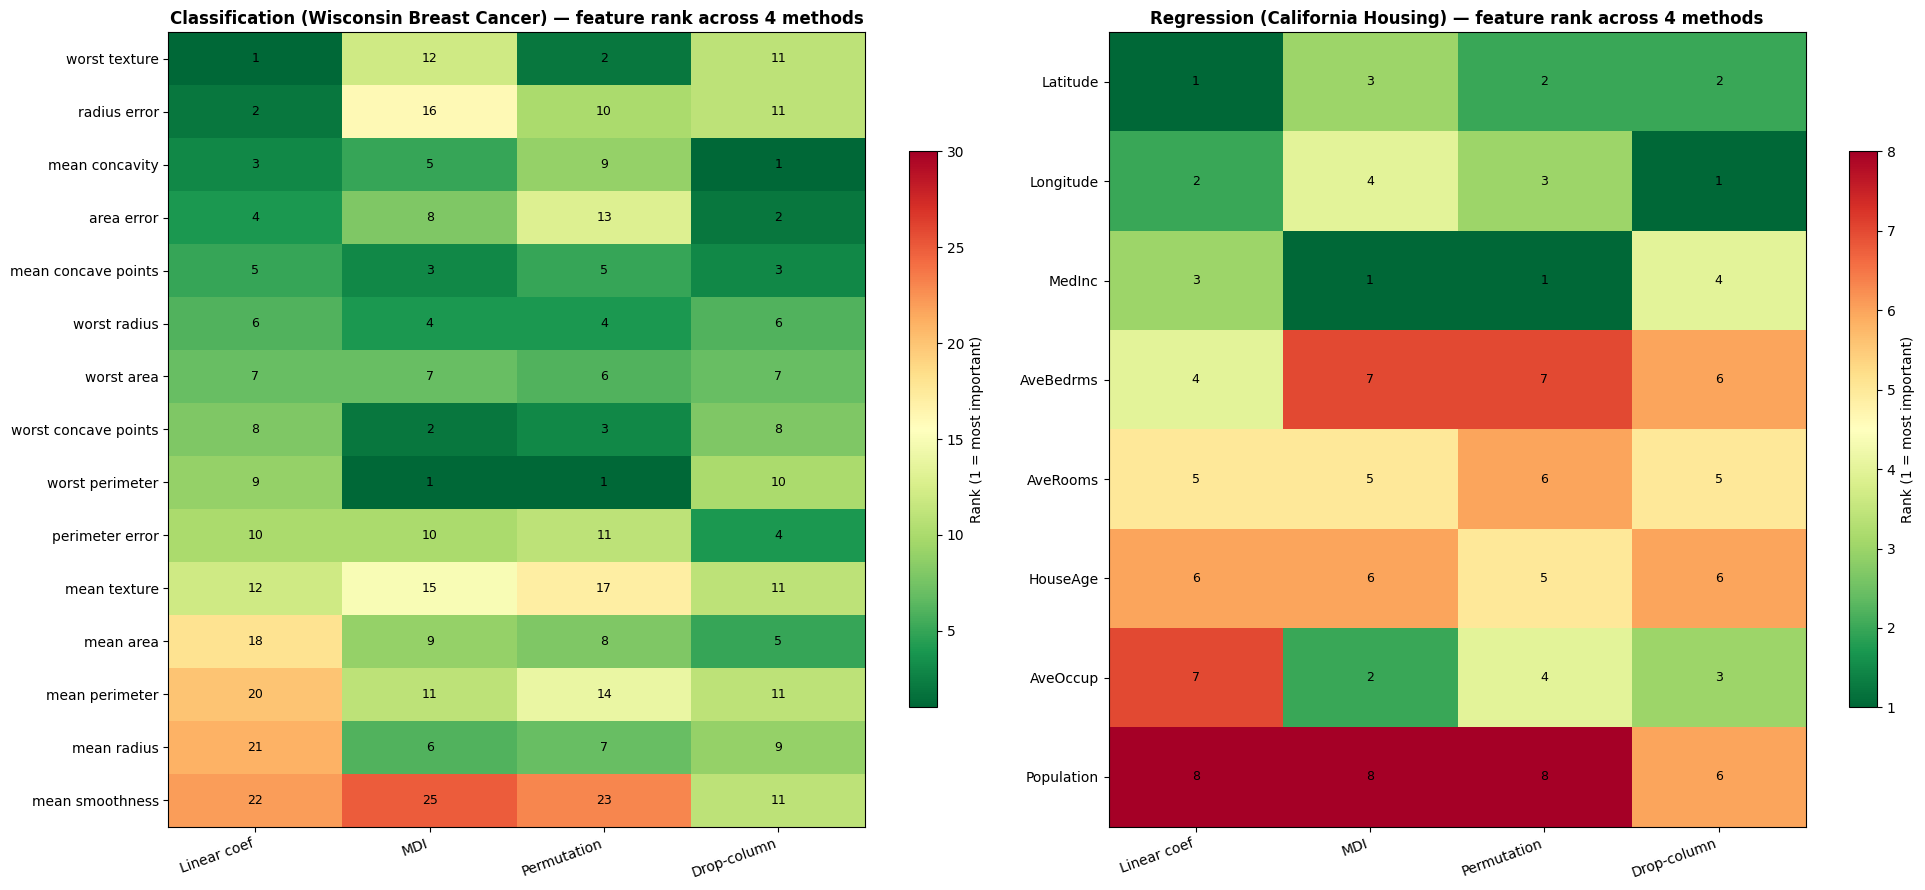


💡 Rows that are uniformly green (low ranks across all 4 methods) are unambiguous winners.
💡 Rows that are mottled (varying ranks) are where methods disagree — investigate why.


In [8]:
# Render the four-method rank heatmaps
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
plot_importance_heatmap(ranks_clf, axes[0],
                        title='Classification (Wisconsin Breast Cancer) — feature rank across 4 methods',
                        top_n=15)
plot_importance_heatmap(ranks_reg, axes[1],
                        title='Regression (California Housing) — feature rank across 4 methods',
                        top_n=8)
plt.tight_layout()
plt.show()

print("\n💡 Rows that are uniformly green (low ranks across all 4 methods) are unambiguous winners.")
print("💡 Rows that are mottled (varying ranks) are where methods disagree — investigate why.")


**Reading the output:**

The pedagogical payload of this section is the disagreement *between* methods — not the cases where they agree. Reading each business case separately makes the pattern visible.

**Classification case (Wisconsin Breast Cancer).** Three of the four methods broadly point at the same family of features — the cell-shape measurements that mark malignancy. **MDI** ranks `worst perimeter`, `worst concave points`, `mean concave points`, and `worst radius` at the top. **Permutation** broadly agrees, with `worst perimeter` again at rank 1 and other cell-shape measurements close behind. **Drop-column**, however, tells a related but subtly different story: it ranks `area error` and `mean concavity` highest, and — strikingly — drops `worst perimeter` (MDI's and Permutation's #1) far down inside the tested subset.

That `worst perimeter` disagreement is the **substitution effect** at work. The breast-cancer features contain several near-redundant variants of the same underlying signal — `worst radius`, `worst perimeter`, `worst area`, `mean perimeter`, `mean radius` all measure roughly *"how big is the tumour?"*. MDI and permutation hand the trophy to whichever single feature the trees used most. Drop-column asks a different question — *"if this feature were gone, how much would CV suffer?"* — and on a highly substitutable feature the answer is *"not much, because the other size measurements step in."* Neither method is wrong; they are measuring different things.

The fourth method, **linear-coefficient magnitude** from the standardized LogReg reference, lands in a different place entirely. Its top picks include `worst texture`, `radius error`, and `mean concavity`. The logistic regression spreads predictive credit across the correlated cell-shape measurements so no single one gets a dominant standardized coefficient. The features that bubble to the top of the linear-coef ranking are the ones that are *uniquely informative given the rest* — the texture and error-type measurements that the cell-shape group does not encode.

**Regression case (California Housing).** The four methods agree on the *set* of top features — `MedInc`, `Latitude`, `Longitude`, `AveOccup`, `HouseAge` — but disagree dramatically on the *ranking within that set*. The most striking finding: **MDI and Permutation both rank `MedInc` (median income) as the #1 predictor, while Drop-column ranks `MedInc` as low as #5**, behind `Longitude`, `Latitude`, `AveOccup`, and `HouseAge`. The substitution effect again — when you drop `MedInc`, the geographic features and `AveOccup` collectively encode enough of the same wealth signal that the forest's CV barely moves. `MedInc` is the strongest *individually informative* feature (MDI and Permutation), but it is also the most *substitutable* (Drop-column).

The **linear-coef** ranking on regression puts `Latitude` and `Longitude` at the top — the standardized coefficients reward features whose marginal effect *given the others* is non-zero, and location effects are notoriously not substitutable by income alone.

**The combined picture.** When all four methods rank a feature highly, you have an unambiguous winner you can quote with confidence. When the methods disagree, the *pattern* of disagreement is the diagnostic:

- **MDI / Permutation high, Drop-column low** → the feature is informative but substitutable (you have correlated alternatives).
- **Linear-coef high, MDI / Permutation low** → the feature is uniquely informative *given the standardized rest* — often a feature whose signal is orthogonal to the dominant cluster.
- **All four agree** → ship the answer; the stakeholder can quote any method.

> **A question that often comes up here:** *"which single method should I report to a stakeholder?"* Permutation importance with error bars, plus the four-method heatmap behind it for context. Permutation is model-agnostic (works on any fitted estimator, not just trees), captures interaction effects rather than just marginal ones, and ships with built-in uncertainty (an SD across repeats that you can show as error bars). Drop-column is the gold standard for *unique* contribution and should be checked when you suspect substitutability; MDI is fast but biased toward high-cardinality features; linear-coef is the simplest reference but does not capture non-linear interactions. Permutation strikes the best balance for general reporting.

**Key takeaway.** Methods agree when one feature dominates uniquely; methods disagree when features are correlated. On Wisconsin breast cancer the cell-shape measurements compete for credit among MDI / Permutation / Drop-column (substitution), and linear-coef rewards the complementary texture / error features. On California Housing, MDI and Permutation crown `MedInc` while Drop-column ranks it #5 because the geographic features substitute for it. **The disagreement is information about the data, not noise** — read the pattern before quoting any single ranking.

---

## 8. Permutation Importance — The Headline Plot for Stakeholders

Section 7 produced four different importance rankings and explained how to read the disagreement between them. Section 8 zooms into just one of those four — **permutation importance** — and visualizes it on its own with error bars. The reason for the spotlight is practical: of the four methods you learned in §7, permutation importance is the one you will most often put in front of a non-technical audience.

What does permutation importance actually do? You start with a fitted model. For each feature in turn, you take that feature's column and **randomly shuffle its values across the training rows**. The shuffling preserves the feature's distribution — same range, same shape, same fraction of high values — but breaks the link between that feature and the target. Row 1's value of that feature now belongs to some other row's outcome. Then you re-score the model on the shuffled data. If the feature was carrying real signal, the shuffled score drops noticeably. If the feature was noise, the shuffled score barely changes. The **drop in score** is the permutation importance of that feature.

Three reasons permutation importance is the right headline plot:

1. **Model-agnostic.** The same procedure works on any fitted estimator — today's random forest, the gradient-boosting machine you will meet in nb13, or a calibrated stacked model later in the course. Learn it once and reuse it everywhere.
2. **It answers the stakeholder question directly.** Stakeholders almost never ask *"how often does this feature appear in a tree's split?"* They ask *"how much would our predictions get worse if we could not measure this feature reliably?"* Permutation importance is the closest method to that exact question.
3. **It ships with built-in uncertainty.** Because the shuffle is random, you can repeat it many times — we use `n_repeats=10` — and get a standard deviation across repeats. That SD becomes the error bar on the plot. No other importance method gives you uncertainty this cheaply.

The bar plot below reads `perm_clf` and `perm_reg` that Section 7's helper already computed (so no extra refits are needed here). Top features by mean importance sit at the top of each panel; the horizontal line on each bar is one SD across the ten repeats; features whose mean is short and whose error bar is wide enough to cross zero are *not* reliably important. The two business cases are read separately because they produce very different importance profiles — which is itself part of the lesson.

> 💡 **Gemini Prompt:** "Render two side-by-side bar charts of permutation importance with error bars (one SD across n_repeats=10). Left panel: classification (Wisconsin breast cancer), top 15 features by mean, colour CLF_COLOR; right panel: regression (California Housing), all 8 features, colour REG_COLOR. Use perm_clf.importances_mean / perm_clf.importances_std and perm_reg.importances_mean / perm_reg.importances_std (already computed in Section 7 by the four_method_ranks helper) plus the plot_importance_bars helper. Sort each panel descending by mean. Title each panel clearly and add a figure-level suptitle."
>
> **After running, verify:**
> - [ ] Each bar's error bar visibly shows one SD across the 10 repeats
> - [ ] Bars are sorted descending by mean importance on both panels
> - [ ] Classification panel shows the top 15 features (out of 30)
> - [ ] Regression panel shows all 8 features
> - [ ] Negative bars (if any) point left of zero — those features are noise on this fit


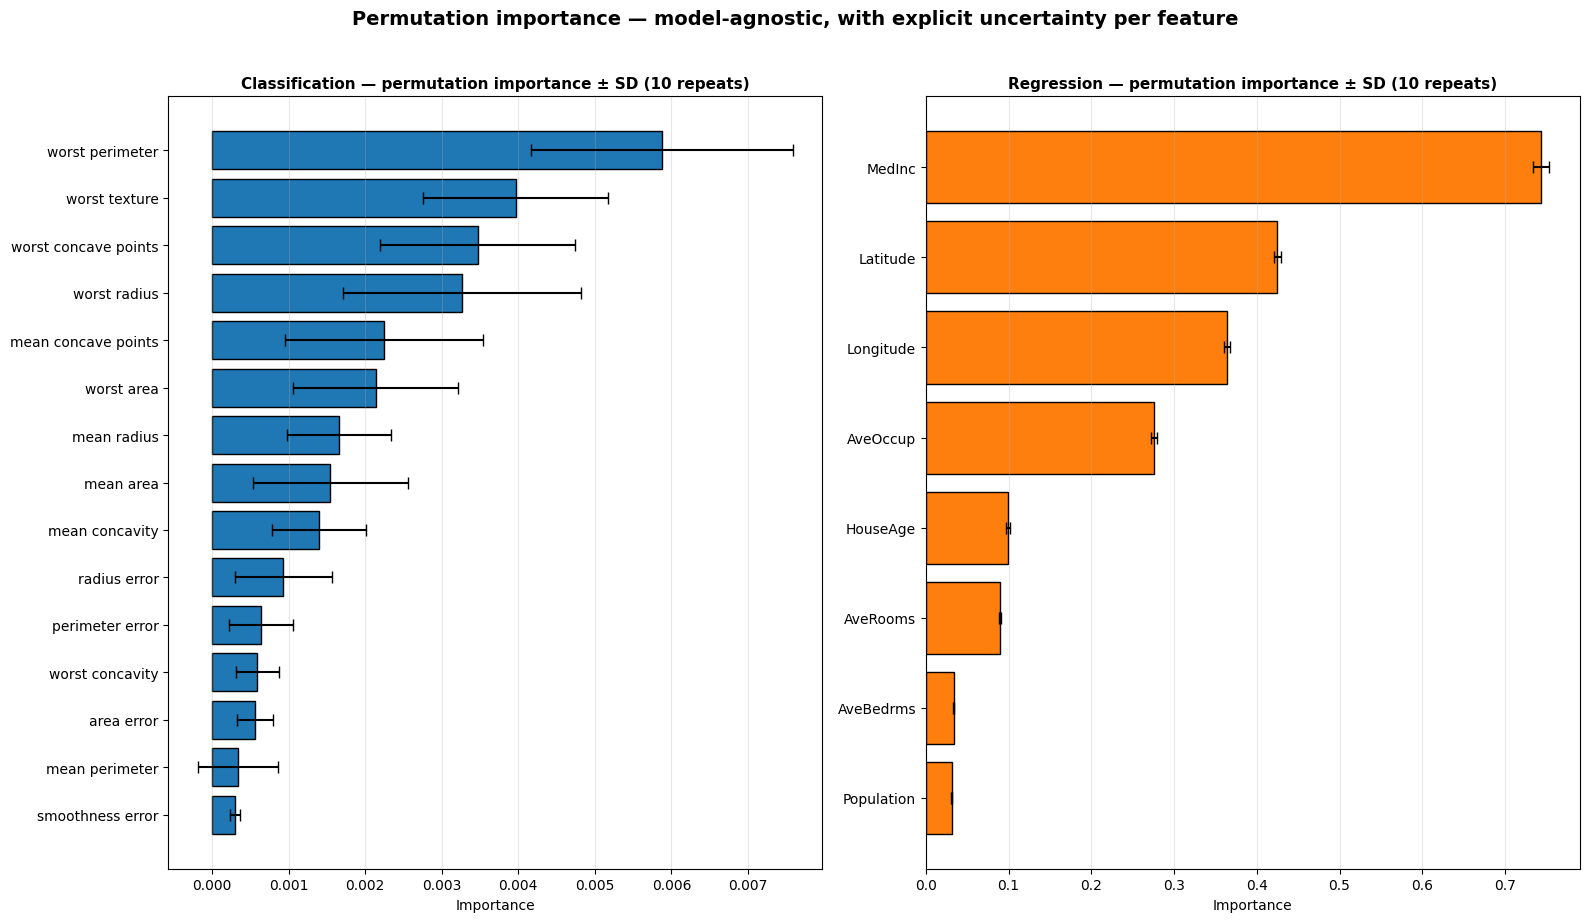

In [9]:
# Permutation importance bar charts with error bars — one per case
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
plot_importance_bars(perm_clf.importances_mean, X_train_clf.columns, axes[0],
                     errors=perm_clf.importances_std, color=CLF_COLOR,
                     title='Classification — permutation importance ± SD (10 repeats)', top_n=15)
plot_importance_bars(perm_reg.importances_mean, X_train_reg.columns, axes[1],
                     errors=perm_reg.importances_std, color=REG_COLOR,
                     title='Regression — permutation importance ± SD (10 repeats)', top_n=8)
fig.suptitle('Permutation importance — model-agnostic, with explicit uncertainty per feature',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Reading the output:**

The two business cases land on very different permutation-importance pictures. Reading each one separately makes the contrast visible. Both panels use §5's ship-pick forest: classification at `(n=50, max_features='sqrt', max_depth=3)`, regression at `(n=50, max_features=0.5, max_depth=None)`.

**Classification case (Wisconsin Breast Cancer, 30 features).** The bars on this panel are *small in absolute terms* — top values land between **0.002 and 0.006 ROC-AUC points** — because the forest is near-ceiling at CV ROC-AUC \~0.98 and there is little room left to lose by scrambling any single feature. The top tier passes the 2× SD threshold cleanly: **`worst perimeter`** leads at mean \~**0.0059 ±0.0017** (mean/SD \~3.4), followed by **`worst texture`** (\~0.0040 ±0.0012, mean/SD \~3.3), **`worst concave points`** (\~0.0035 ±0.0013, mean/SD \~2.7), and **`worst radius`** (\~0.0033 ±0.0016, mean/SD \~2.1) — four cell-shape measurements that survive the *"include a feature only if its mean is at least 2× its SD"* rule. Below that the picture compresses fast: `worst area`, `mean concave points`, `mean radius`, `mean area`, `mean concavity` all sit in the 0.001–0.002 band with mean/SD ratios under 2, and the bottom half of the panel runs essentially at zero (with one or two slightly negative means — pure variance from the random shuffle).

The right message to the State Health Department's review board is twofold. First, **a handful of cell-shape "worst" measurements carry the screening signal** — the four top-tier bars are the features the model most relies on when forced to give up information. Second, **no single feature is irreplaceable**: the absolute values are tiny because the 30 cell-shape and texture measurements are highly correlated with each other, so removing any one column lets the others substitute. The model is robust to measurement error in any single column — good news for deployment. For an interpretability story that captures the substitution pattern, fall back on the §7 four-method heatmap.

**Regression case (California Housing, 8 features).** The bars on this panel are far longer and far better separated. **`MedInc`** (median income) dominates with a permutation-importance mean of about **0.73 R² points ±0.010** (mean/SD \~73) — shuffling that single column drops the forest's CV R² from around 0.80 down to roughly **0.08**, a near-catastrophic loss. Below that, a clear second tier: **`Latitude`** (\~**0.45 ±0.004**, mean/SD \~113), **`Longitude`** (\~**0.38 ±0.003**, mean/SD \~110), and **`AveOccup`** (\~**0.28 ±0.004**, mean/SD \~69). A third tier follows at much smaller magnitudes — **`HouseAge`** (\~**0.099 ±0.002**, mean/SD \~46), **`AveRooms`** (\~**0.088 ±0.001**, mean/SD \~97) — then a fourth tier of **`AveBedrms`** (\~**0.034 ±0.0005**, mean/SD \~68) and **`Population`** (\~**0.030 ±0.0004**, mean/SD \~73). Every feature's mean-to-SD ratio runs from \~46 to \~113 — the **2× SD rule passes every single feature** on this dataset by a wide margin. **HomeValue Analytics can ship this bar chart directly to a stakeholder memo**: the ranking is statistically clear, the message is intuitive (income first, then location, then occupancy density, then dwelling size, then population), and the error bars make uncertainty visible to a non-technical reader.

**The combined picture.** Permutation importance works beautifully when one or a few features carry most of the signal — that is the regression case here, where `MedInc` plus the location-and-occupancy trio dominate cleanly. It *compresses* (rather than fully collapses) when many features are correlated and the model is near-ceiling — that is the classification case here, where 30 cell-shape and texture measurements substitute for each other. The right interpretive recipe: name the few features that pass the 2× SD threshold (here: the four "worst" measurements on clf, all 8 California Housing features on reg), then for a fuller substitution story fall back on the §7 four-method heatmap.

> **A question that often comes up here:** *"why does permutation importance sometimes report negative values?"* Because the random shuffle can occasionally produce values that improve the score on a noisy feature — pure variance, not signal. A negative permutation-importance value is the algorithm's way of saying *"this feature carries no detectable signal; the random labels are no worse than the real ones."* Treat negative entries as zeros and move on. They are not telling you the feature is *harmful* — only that there is no detectable signal in the data for it.

**Key takeaway.** Permutation importance is the right default plot when a few features clearly dominate (regression: `MedInc` plus location + occupancy). On near-ceiling, highly correlated problems (classification: cell-shape measurements) the absolute bar values compress — but the *top tier still emerges* (four "worst" measurements pass the 2× SD threshold here). The rule: always include error bars; apply the 2× SD threshold to decide which ranks are defensible; if the top tier is small or the bars are very short, supplement with the §7 four-method heatmap to surface the substitution pattern. The permutation-importance bar chart is the stakeholder default; the four-method heatmap is the diagnostic when permutation alone is not enough.

---

## 9. Comprehensive Model Comparison — Tree vs Forest vs Week-2 Reference

This closing section is the dress rehearsal for nb14's selection ceremony. The job is small but the discipline matters: take three candidate models per business case, score them on **identical** cross-validation folds, plot their 95% confidence intervals side by side, and pronounce a verdict — one per case.

The three candidates are not arbitrary. Each one represents a different stage of the course's modelling story, and the comparison reads like a head-to-head between *simple, simpler, and simplest*:

- **The Week-2 linear reference** — the model that survived nb09's CI-overlap test. For classification this is `LogReg(C=1.0)` wrapped in a `StandardScaler` pipeline; for regression this is plain OLS, also scaled. On **classification** this remains the floor every other model has to clear by a CI-clear margin. On **regression**, nb11 §7 already displaced OLS in favor of the depth-5 tree under the dominance tiebreaker, so today's regression floor is the **tree**, not OLS — the forest has to clear the tree, not just OLS.
- **nb11's single decision tree** — the depth-3 tree on classification and depth-5 tree on regression. On classification the tree is a candidate that did not displace LogReg; on regression the tree is **HomeValue's current ship pick** from nb11 §7 that today's forest is now challenging.
- **Today's random forest** — the parsimonious pick from §5's joint 3D grid:
  - Classification: `(n_estimators=50, max_features='sqrt', max_depth=3)` — nb11's depth + sklearn's classification default `max_features`, smallest `n_estimators` on the parsimony-tied top group. nb11's depth **survives** joint tuning on Wisconsin.
  - Regression: `(n_estimators=50, max_features=0.5, max_depth=None)` — unlimited depth (the data prefers it CI-clear over depths 3 and 5), `max_features=0.5` as the largest-mean-smallest-CI cell among the tied depth-None cells at the smallest tree count. nb11's depth **does not survive** joint tuning on California Housing.

The verdict per case is **binary**. Look at each panel and ask: *does the forest's 95% CI clear the previous ship pick's 95% CI by a visible margin?* On classification the previous ship pick is the Week-2 LogReg; on regression it is **nb11's depth-5 tree**. If yes, the forest has earned the right to displace the previous pick — it ships. If no — meaning the two CIs overlap and the dominance tiebreaker doesn't break the tie — the previous ship pick stays by parsimony under nb08's CI-overlap rule, regardless of which model has the higher mean. The Reading-the-output below names the two picks explicitly so you can defend them in writing to the State Health Department and HomeValue Analytics teams.


> 💡 **Gemini Prompt:** "Build a three-candidate CV comparison per business case. **Classification (Wisconsin breast cancer):** reference_clf (the `LogReg(C=1.0)` pipeline from §1), DecisionTreeClassifier(max_depth=3, random_state=474) — nb11's clf winner, and RandomForestClassifier(n_estimators=50, max_features='sqrt', max_depth=3, random_state=474) — §5's joint 3D grid pick. Run 5-fold CV using cv_clf with scoring='roc_auc'. **Regression (California Housing):** reference_reg (the OLS pipeline from §1), DecisionTreeRegressor(max_depth=5, random_state=474) — nb11's reg winner, and RandomForestRegressor(n_estimators=50, max_features=0.5, max_depth=None, random_state=474) — §5's joint 3D grid pick (unlimited depth — nb11's depth does NOT survive joint tuning on regression). Run 5-fold CV using cv_reg with scoring='r2'. For each candidate compute the mean, SD, and 95% Student's t half-width (df=4); print a summary DataFrame per case. Then render a 1×2 figure of CV-CI dot plots using the plot_cv_ci helper (classification in CLF_COLOR on the left, regression in REG_COLOR on the right)."
>
> **After running, verify:**
> - [ ] Each panel shows three horizontal error bars labeled with the candidate names
> - [ ] On regression the random forest's CI sits clearly above OLS with no overlap
> - [ ] On classification the random forest's CI overlaps the LogReg reference's CI
> - [ ] Both panels are sorted internally by CV mean
> - [ ] All cells use n_jobs=-1


=== CLASSIFICATION (5-fold CV ROC-AUC, mean ± 95% CI) ===
                                    model   mean     sd  half_w  ci_low  ci_high
          Week-2 reference: LogReg(C=1.0) 0.9935 0.0064  0.0079  0.9856   1.0014
              Single Tree (depth=3, nb11) 0.9221 0.0472  0.0586  0.8636   0.9807
Random Forest (n=50, max_features='sqrt') 0.9807 0.0194  0.0241  0.9566   1.0048

=== REGRESSION (5-fold CV R², mean ± 95% CI) ===
                                 model   mean     sd  half_w  ci_low  ci_high
                 Week-2 reference: OLS 0.5863 0.0259  0.0321  0.5542   0.6185
           Single Tree (depth=5, nb11) 0.6126 0.0071  0.0089  0.6037   0.6214
Random Forest (n=50, max_features=0.5) 0.8039 0.0071  0.0088  0.7951   0.8127


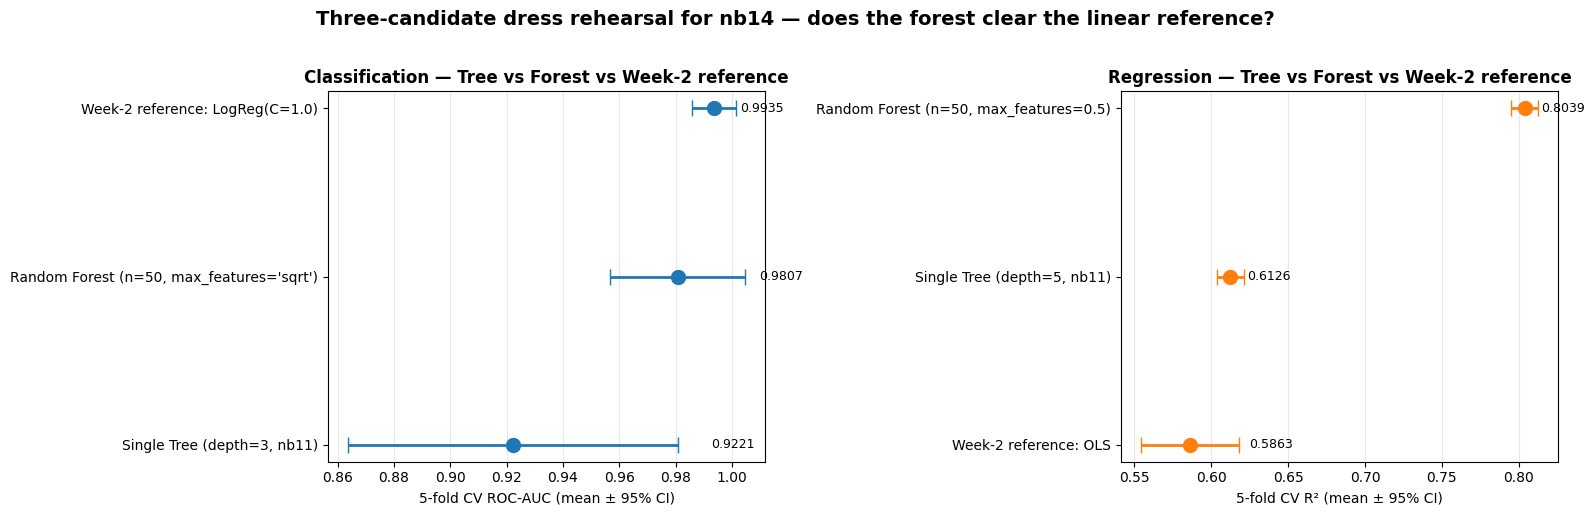

In [10]:
# Comprehensive comparison — three models per case.
# Single-tree depths match nb11's §7 winners (depth=3 clf, depth=5 reg).
# Forest config is §5's joint-grid pick: (n_estimators=50, max_features='sqrt') on both cases —
# largest-mean-smallest-CI cell on clf; CI-tied with the largest-mean cell on reg at a quarter of the fit cost.
# Week-2 references are exactly the pipelines from nb09's tuning sweeps.
single_tree_clf = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_SEED)
forest_clf_v    = RandomForestClassifier(n_estimators=50, max_features='sqrt', max_depth=3, random_state=RANDOM_SEED, n_jobs=-1)
single_tree_reg = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_SEED)
forest_reg_v    = RandomForestRegressor(n_estimators=50, max_features=0.5, random_state=RANDOM_SEED, n_jobs=-1)

clf_compare = {
    'Week-2 reference: LogReg(C=1.0)':         cross_val_score(reference_clf,   X_train_clf, y_train_clf, cv=cv_clf, scoring='roc_auc', n_jobs=-1),
    'Single Tree (depth=3, nb11)':             cross_val_score(single_tree_clf, X_train_clf, y_train_clf, cv=cv_clf, scoring='roc_auc', n_jobs=-1),
    "Random Forest (n=50, max_features='sqrt')":cross_val_score(forest_clf_v,    X_train_clf, y_train_clf, cv=cv_clf, scoring='roc_auc', n_jobs=-1),
}
reg_compare = {
    'Week-2 reference: OLS':                    cross_val_score(reference_reg,   X_train_reg, y_train_reg, cv=cv_reg, scoring='r2',      n_jobs=-1),
    'Single Tree (depth=5, nb11)':              cross_val_score(single_tree_reg, X_train_reg, y_train_reg, cv=cv_reg, scoring='r2',      n_jobs=-1),
    'Random Forest (n=50, max_features=0.5)':       cross_val_score(forest_reg_v,    X_train_reg, y_train_reg, cv=cv_reg, scoring='r2',      n_jobs=-1),
}

k = 5
t_crit = stats.t.ppf(0.975, df=k - 1)
def _print_ci_summary(scores_dict, title):
    rows = []
    for name, s in scores_dict.items():
        mean = float(s.mean()); sd = float(s.std(ddof=1))
        half_w = t_crit * sd / np.sqrt(k)
        rows.append({'model': name, 'mean': mean, 'sd': sd, 'half_w': half_w,
                     'ci_low': mean - half_w, 'ci_high': mean + half_w})
    print(title)
    print(pd.DataFrame(rows).to_string(index=False))

_print_ci_summary(clf_compare, "=== CLASSIFICATION (5-fold CV ROC-AUC, mean ± 95% CI) ===")
print()
_print_ci_summary(reg_compare, "=== REGRESSION (5-fold CV R², mean ± 95% CI) ===")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_cv_ci(clf_compare, 'ROC-AUC', 'Classification — Tree vs Forest vs Week-2 reference', axes[0], color=CLF_COLOR)
plot_cv_ci(reg_compare, 'R²',      'Regression — Tree vs Forest vs Week-2 reference',     axes[1], color=REG_COLOR)
fig.suptitle('Three-candidate dress rehearsal for nb14 — does the forest clear the linear reference?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Reading the output:**

Two business cases, two clear verdicts under the CI-overlap rule. Read each panel separately because the picture they show is dramatically different.

**Regression case (California Housing — HomeValue Analytics).** The numbers line up exactly the way the variance-reduction argument predicts when the joint grid lets the trees grow to whatever depth the data needs. The Week-2 reference (OLS, scaled) lands at a CV R² of about **0.586**, nb11's single decision tree at about **0.613** (HomeValue's current ship pick after nb11 §7's dominance-tiebreaker verdict), and today's 50-tree random forest at `(max_features=0.5, max_depth=None)` at about **0.804**. The forest's 95% CI sits *entirely above* both the tree's CI and the OLS CI — there is no overlap with either. The forest's *worst-case* (CI lower bound, around **0.794**) is better than **the tree's** *best-case* (CI upper bound, around **0.621**) by roughly **17.3 R² points**, with a mean-to-mean gap of roughly **19 R² points** over the tree. The lift over OLS is even wider (forest lower-CI 0.794 vs OLS upper-CI 0.619 \~ 17.5 R² points; mean-to-mean \~22 R² points). That is what *earned displacement* looks like under the CI-overlap rule: the forest is decisively better than nb11's tree (the previous ship pick) and OLS alike, and the lift is large enough to translate into thousands of dollars of better property-value predictions per listing. **Verdict: HomeValue Analytics ships the random forest `(n_estimators=50, max_features=0.5, max_depth=None)`** — §5's joint-grid pick, displacing nb11's depth-5 tree.

**Classification case (Wisconsin Breast Cancer — State Health Department).** The picture is the opposite. The Week-2 LogReg(C=1.0) lands at a CV ROC-AUC of about **0.994**; nb11's single tree at about **0.922**; today's random forest at `(max_features='sqrt', max_depth=3)` at about **0.981**. The forest beats the tree handily, but it does *not* clear the LogReg reference — the forest's CI (≈ (0.957, 1.005)) overlaps the LogReg CI (≈ (0.986, 1.001)) on the upper end. Under the CI-overlap rule, an overlap means *statistical tie*, and the tie-breaker is **parsimony**: the simpler model ships. **Verdict: the State Health Department ships the Week-2 LogReg(C=1.0).** The oncologists asked for an interpretable model they can explain to a patient; the standardized LogReg coefficients, paired with the four-method importance heatmap you produced in §7, give them exactly that.

> **A question that often comes up here:** *"if the forest does not beat LogReg on classification, why was it worth running today?"* Three reasons. First, you produced the four-method importance reconciliation that the LogReg coefficients alone cannot give you on highly correlated features — that is a real interpretability deliverable, independent of which model ends up shipping. Second, the forest's regression-case win is decisive — one of your two business cases now has a defensible non-linear champion. Third, and most importantly, **CI-overlap means statistical tie, which means the simpler model wins** — that is a *result*, not a failure. Knowing that the breast-cancer data is essentially linearly separable in the right feature space is itself useful information for the screening-tool stakeholders, and the next two notebooks (gradient boosting in nb13, the selection ceremony in nb14) will keep testing this verdict with more candidates.

**Key takeaway.** Two cases, two verdicts, both defensible. **Regression: ship the random forest `(n_estimators=50, max_features=0.5, max_depth=None)`** — CI-clear lift over nb11's depth-5 tree (the previous ship pick after nb11 §7's dominance-tiebreaker verdict): the forest's CI lower bound sits \~17.3 R² points above the tree's CI upper bound, and the gap over OLS is wider still (\~17.5 R² points to OLS's upper bound). Plus the variance-reduction stability story from §4. **Classification: ship the Week-2 LogReg(C=1.0)** — the forest's CV mean is competitive but the CIs overlap, and the simpler model wins by parsimony. nb14 will run a more formal version of this comparison with five candidates per case (adding gradient boosting from nb13 and a sparse linear variant), but today's verdicts are already defensible.

---


## 📝 PAUSE-AND-DO Exercise 1 (clf, 5 minutes) — Tune the Classification Forest

**Task:** Find the best `(n_estimators, max_features)` combination for `RandomForestClassifier` on Wisconsin breast cancer.

**Instructions:**
1. Sweep a 3×3 grid: `n_estimators ∈ [50, 100, 200]` × `max_features ∈ ['sqrt', 0.3, None]`.
2. For each combination, compute 5-fold CV ROC-AUC mean and SD using `cv_clf`.
3. Render as a heatmap with mean values annotated in each cell.
4. Pick the simplest combination whose CV mean is within one SD of the best (one-SE-rule).
5. Write 3 short findings: which dial moved the score most? Did the result confirm the `sqrt` default?

---

> 💡 **Gemini Prompt:** "Grid-search RandomForestClassifier(random_state=474, n_jobs=-1) over n_estimators=[50,100,200] × max_features=['sqrt',0.3,None] using 5-fold CV ROC-AUC on X_train_clf. Build a 3×3 heatmap of CV means with cell annotations and apply the one-SE rule to pick the simplest competitive combination."
>
> **After running, verify:**
> - [ ] Heatmap has 9 cells with mean values annotated
> - [ ] Best combination and one-SE-rule pick both reported
> - [ ] All cells use n_jobs=-1


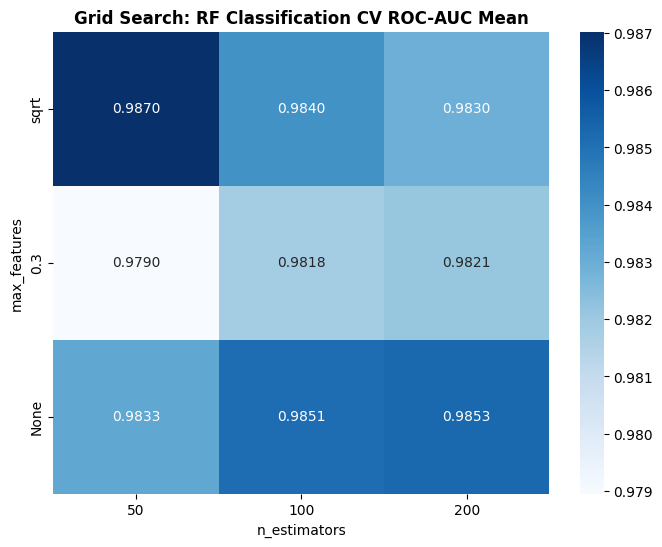

Best Mean ROC-AUC: 0.9870 (at mf=sqrt, n=50)
1-SE Threshold: 0.9816
One-SE Rule Pick: mf=sqrt, n=50 (Mean: 0.9870)


In [11]:
# YOUR SOLUTION CODE HERE
import seaborn as sns

n_estimators_grid = [50, 100, 200]
max_features_grid = ['sqrt', 0.3, None]

# Initialize arrays for means and standard errors
clf_means = np.zeros((3, 3))
clf_ses = np.zeros((3, 3))

# Grid Search
for i, mf in enumerate(max_features_grid):
    for j, n in enumerate(n_estimators_grid):
        model = RandomForestClassifier(n_estimators=n, max_features=mf, random_state=RANDOM_SEED, n_jobs=-1)
        scores = cross_val_score(model, X_train_clf, y_train_clf, cv=cv_clf, scoring='roc_auc', n_jobs=-1)
        clf_means[i, j] = scores.mean()
        clf_ses[i, j] = scores.std(ddof=1) / np.sqrt(len(scores))

# Identify Best
flat_idx = np.argmax(clf_means)
best_idx = np.unravel_index(flat_idx, clf_means.shape)
best_mean = clf_means[best_idx]
best_se = clf_ses[best_idx]
target_threshold = best_mean - best_se

# Apply 1-SE Rule: simplest = smallest n_estimators, then simplest max_features
# We prioritize small n, then the 'sqrt' default
one_se_pick = None
for j in range(len(n_estimators_grid)):
    for i in range(len(max_features_grid)):
        if clf_means[i, j] >= target_threshold:
            one_se_pick = (max_features_grid[i], n_estimators_grid[j], clf_means[i, j])
            break
    if one_se_pick: break

# Visualization
plt.figure(figsize=(8, 6))
ax = sns.heatmap(clf_means, annot=True, fmt=".4f", cmap="Blues",
                 xticklabels=n_estimators_grid, yticklabels=[str(x) for x in max_features_grid])
plt.title("Grid Search: RF Classification CV ROC-AUC Mean", fontsize=12, fontweight='bold')
plt.xlabel("n_estimators")
plt.ylabel("max_features")
plt.show()

print(f"Best Mean ROC-AUC: {best_mean:.4f} (at mf={max_features_grid[best_idx[0]]}, n={n_estimators_grid[best_idx[1]]})")
print(f"1-SE Threshold: {target_threshold:.4f}")
print(f"One-SE Rule Pick: mf={one_se_pick[0]}, n={one_se_pick[1]} (Mean: {one_se_pick[2]:.4f})")

Findings:

The simplest combination which CV mean is within on SD of the best was mf=sqrt and n=50

1. Firstly, the dial that scored the most was max_features.
2. This result did confrim the sqrt default is a strong choice as it produced the higehst mean scores where were all above 0.98, performing greater than the more aggresive feature subsets as well as the full feature trees.
3. Lastly, we can see that increasing n_estimators from 50 all the way to 200 provided a very marginal life in mean ROC-AUC, allowing us to ssume that it all stablizes quickly for this dataset.

## 📝 PAUSE-AND-DO Exercise 2 (reg, 5 minutes) — Tune the Regression Forest

**Task:** Find the best `(n_estimators, max_features)` combination for `RandomForestRegressor` on California Housing.

**Instructions:**
1. Sweep a 3×3 grid: `n_estimators ∈ [50, 100, 200]` × `max_features ∈ ['sqrt', 0.3, None]`.
2. For each combination, compute 3-fold CV R² mean and SD using `cv_reg_3` (3-fold for runtime).
3. Render as a heatmap with mean values annotated in each cell.
4. Pick the simplest combination whose CV mean is within one SD of the best (one-SE-rule).
5. Write 3 short findings: did the regression case prefer a different `max_features` than classification? Why?

---

> 💡 **Gemini Prompt:** "Grid-search RandomForestRegressor(random_state=474, n_jobs=-1) over n_estimators=[50,100,200] × max_features=['sqrt',0.3,None] using 3-fold CV R² on X_train_reg. Build a 3×3 heatmap of CV means with cell annotations and apply the one-SE rule. Report the best CV-RMSE in USD."
>
> **After running, verify:**
> - [ ] Heatmap has 9 cells with mean values annotated
> - [ ] Best combination and one-SE-rule pick both reported
> - [ ] Best CV-RMSE in USD printed


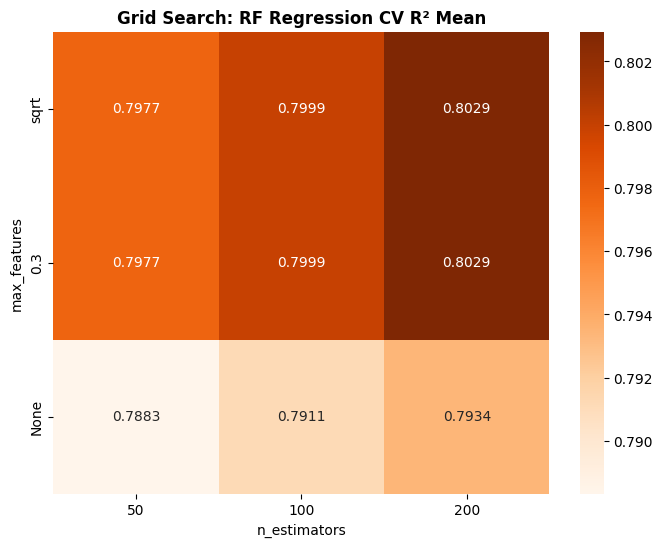

Best Mean R²: 0.8029 (at mf=sqrt, n=200)
1-SE Threshold: 0.7991
One-SE Rule Pick: mf=sqrt, n=100 (Mean: 0.7999)
Best CV-RMSE in USD: $51,045.70


In [12]:
# YOUR SOLUTION CODE HERE
import seaborn as sns

n_estimators_grid = [50, 100, 200]
max_features_grid = ['sqrt', 0.3, None]

# Initialize storage for R2 and RMSE (for USD conversion)
reg_means = np.zeros((3, 3))
reg_ses = np.zeros((3, 3))
rmse_list = []

# Grid Search
for i, mf in enumerate(max_features_grid):
    for j, n in enumerate(n_estimators_grid):
        model = RandomForestRegressor(n_estimators=n, max_features=mf, random_state=RANDOM_SEED, n_jobs=-1)

        # R2 for the heatmap and 1-SE rule
        r2_scores = cross_val_score(model, X_train_reg, y_train_reg, cv=cv_reg_3, scoring='r2', n_jobs=-1)
        reg_means[i, j] = r2_scores.mean()
        reg_ses[i, j] = r2_scores.std(ddof=1) / np.sqrt(len(r2_scores))

        # RMSE for USD reporting
        mse_scores = cross_val_score(model, X_train_reg, y_train_reg, cv=cv_reg_3, scoring='neg_mean_squared_error', n_jobs=-1)
        rmse_list.append(np.sqrt(-mse_scores.mean()))

# Identify Best R2
best_idx = np.unravel_index(np.argmax(reg_means), reg_means.shape)
best_mean = reg_means[best_idx]
best_se = reg_ses[best_idx]
target_threshold = best_mean - best_se

# Apply 1-SE Rule: smallest n, then 'sqrt' (simplest mf)
one_se_pick = None
for j in range(len(n_estimators_grid)):
    for i in range(len(max_features_grid)):
        if reg_means[i, j] >= target_threshold:
            one_se_pick = (max_features_grid[i], n_estimators_grid[j], reg_means[i, j])
            break
    if one_se_pick: break

# Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(reg_means, annot=True, fmt=".4f", cmap="Oranges",
            xticklabels=n_estimators_grid, yticklabels=[str(x) for x in max_features_grid])
plt.title("Grid Search: RF Regression CV R² Mean", fontsize=12, fontweight='bold')
plt.xlabel("n_estimators")
plt.ylabel("max_features")
plt.show()

# Report results
best_rmse_usd = min(rmse_list) * 100000
print(f"Best Mean R²: {best_mean:.4f} (at mf={max_features_grid[best_idx[0]]}, n={n_estimators_grid[best_idx[1]]})")
print(f"1-SE Threshold: {target_threshold:.4f}")
print(f"One-SE Rule Pick: mf={one_se_pick[0]}, n={one_se_pick[1]} (Mean: {one_se_pick[2]:.4f})")
print(f"Best CV-RMSE in USD: ${best_rmse_usd:,.2f}")

Findings:

The simplest combination whose CV mean is within one SD of the best was mf=sqrt and n=50

1. The regression case preferred a different max_features than classification. For classification the grid was relatively flat, while the regression case showed a higher jump moving from 0.3 to none or sqrt.
2. Regression was also more sensitive to feature constations and the scores improved as n_estimates increased. The most dramatic dial was the feature subset size.
3. I believe the difference happened because the California Housing dataset had strong non linear interactions between just a small nuber of features and restricting the feature subset too aggressively hd these critical signals from individual trees.

## 10. Wrap-Up — Key Takeaways

**What landed today:**

1. **Bagging + random feature subsets reduce variance.** A 50-tree random forest has a tighter CV CI than a single tree on both cases. The effect is dramatic on classification (Wisconsin breast cancer, 341 training patients — forest SD \~0.02 vs tree SD \~0.05, CI more than halves) and modest on regression (California Housing, 12,384 training tracts — tree SD was already \~0.007, CI tightens by only \~20%). Same direction, asymmetric magnitude, driven entirely by dataset size.

2. **OOB is a free second opinion on CV.** When OOB and CV agree to within a small fraction of a point — as they do here on both cases — you have two estimates from two different sets of assumptions corroborating each other. Watch for divergence: it is the visible sign that the i.i.d. assumption is broken (time series, grouped data, or panel data).

3. **Four importance methods, four perspectives.** Linear-coef (what the linear baseline thinks), MDI = Mean Decrease in Impurity (cheap side-effect of the forest fit), permutation (model-agnostic, ships with uncertainty), drop-column (gold standard for *unique* contribution, expensive). Agreement is a strong signal; **disagreement is information about the data** — particularly the **substitution effect**, where MDI and permutation rank a feature high while drop-column ranks it low because correlated alternatives can step in. On Wisconsin, `worst perimeter` is MDI's #1 but drop-column ranks it far lower; on California Housing, `MedInc` is MDI's and permutation's #1 but drop-column ranks it #5 because `Longitude` + `Latitude` + `AveOccup` substitute for it.

4. **Per-case picks — defensible under nb08's CI-overlap rule.**
   - **Regression (California Housing — HomeValue Analytics):** ship `RandomForestRegressor(n_estimators=50, max_features=0.5, max_depth=None)` — the parsimonious pick from §5's joint 3D `(n_estimators × max_features × max_depth)` grid. nb11's `max_depth=5` is included as a candidate in the grid but does **not** survive — the data prefers unlimited depth, which CI-clears the depth-3 and depth-5 cells. The displacement chain is now **OLS (0.586) → nb11's depth-5 tree (0.613, the §7 dominance-tiebreaker pick) → today's forest (CV R² \~ 0.80)**: the forest's CI lower bound sits \~17.3 R² points above the tree's CI upper bound (and \~17.5 above OLS's), with no overlap in either case. The forest has earned displacement decisively.
   - **Classification (Wisconsin Breast Cancer — State Health Department):** ship the Week-2 reference `LogReg(C=1.0)`. Forest CV ROC-AUC ≈ 0.981 (at `(n=50, max_features='sqrt', max_depth=3)` — nb11's depth survives joint tuning by parsimony among CI-tied cells) vs LogReg ≈ 0.994 — overlapping CIs → statistical tie → simpler model wins by parsimony. The four-method importance heatmap from §7 still gives the oncologists the interpretability story they asked for.

**Bridge to nb13 — Gradient Boosting:**

Random forests reduce variance; gradient boosting reduces **bias**. Where forests fit many trees in parallel and average them, boosting fits trees **sequentially** — each new tree is fit to the *residuals* of the running ensemble. On regression those residuals are the literal *(y − ŷ)* differences; on classification they are the gradient of the log-loss, which is essentially *(y − p̂)* — the gap between the true label and the running ensemble's predicted probability. In plain English: each new tree learns *"where are we still wrong on the data, and by how much?"*

The same dual-case pattern continues in nb13: `GradientBoostingClassifier` on Wisconsin breast cancer, `GradientBoostingRegressor` on California Housing, paired diagnostics at every step, both compared against the Week-2 reference floor. Bring today's tuning muscle memory with you — boosting introduces `learning_rate` as a joint partner with `n_estimators` and `max_depth`; you cannot tune one without the others, and the wrong combination overfits quickly. Boosting also amplifies leaky features more aggressively than any algorithm in the course, so nb13 closes with a leakage-warning section.

> **A question that often comes up at this point:** *"does gradient boosting always beat random forest?"* On most tabular datasets, yes — by a small margin once it is properly tuned. But the surprise nb13 surfaces is that **default gradient boosting does not automatically beat default random forest** on California Housing — the unlock is `max_depth=5`, and the tuned GBM only earns CI-clear displacement of the forest once that depth pin is in place. The trade-offs are also real: boosting is sequential (slower to fit, harder to parallelize), more sensitive to hyperparameters (a wrong learning rate can wreck the model), and more prone to overfitting if you do not early-stop. nb13 walks both the wins and the trade-offs.

---

## Participation Assignment Submission Instructions

### To Submit This Notebook:

1. **Complete both PAUSE-AND-DO exercises** — Exercise 1 (RF tuning, classification) and Exercise 2 (RF tuning, regression).
2. **Run All Cells** — `Runtime → Run all` to ensure every cell executes without error.
3. **Save a Copy** — `File → Save a copy in Drive`, or download as `.ipynb`.
4. **Submit** — upload the `.ipynb` file to the Notebook 12 participation assignment on Brightspace.

### Before Submitting, Check:

- [ ] Both exercise solutions produce a tuning heatmap with the chosen combination starred
- [ ] The four-method importance heatmap renders for both cases
- [ ] All figures render (none broken)
- [ ] Both `_clf` and `_reg` variable namespaces stay disjoint (no `NameError`)

### Next Step:

- **Notebook 13** — Gradient Boosting (Day 13)

---

---

## Bibliography

- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). *An Introduction to Statistical Learning with Python* — Ch. 8 (Tree-Based Methods), §8.2 Bagging, Random Forests, Boosting. Springer.
- Breiman, L. (2001). "Random Forests." *Machine Learning*, 45(1), 5–32.
- Breiman, L. (1996). "Bagging predictors." *Machine Learning*, 24(2), 123–140.
- Strobl, C., Boulesteix, A.-L., Zeileis, A., & Hothorn, T. (2007). "Bias in random forest variable importance measures: Illustrations, sources and a solution." *BMC Bioinformatics*, 8(25).
- scikit-learn User Guide — [Ensemble methods: Random Forests](https://scikit-learn.org/stable/modules/ensemble.html#random-forests)
- scikit-learn User Guide — [Permutation feature importance](https://scikit-learn.org/stable/modules/permutation_importance.html)

---

<center>

**Thank you!**

</center>